# Bitcoin Trading Bot Optimisation with WOA and PSO

## 1. Data Loading & Preprocessing

This section loads the daily data from `data/BTC-Daily.csv`, sorts it in ascending date order, and uses the `close` price as the main price series. Data before 2020-01-01 is used as the training data, while data from 2020-01-01 onward is reserved as the test data.

In [1]:
# Basic environment setup
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(OUTPUT_DIR / ".mplconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_PATH = PROJECT_ROOT / "data" / "BTC-Daily.csv"
SPLIT_DATE = pd.Timestamp("2020-01-01")

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# Load and preprocess daily OHLCV data
required_columns = [
    "unix", "date", "symbol", "open", "high", "low", "close", "Volume BTC", "Volume USD"
]

price_data = pd.read_csv(DATA_PATH)
missing_columns = sorted(set(required_columns) - set(price_data.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

price_data = price_data[required_columns].copy()
price_data["date"] = pd.to_datetime(price_data["date"])

numeric_columns = ["open", "high", "low", "close", "Volume BTC", "Volume USD"]
for column in numeric_columns:
    price_data[column] = pd.to_numeric(price_data[column], errors="coerce")

price_data = price_data.sort_values("date").reset_index(drop=True)
price_data = price_data.drop_duplicates(subset="date", keep="last")
price_data = price_data.set_index("date")

if price_data[numeric_columns].isna().any().any():
    bad_counts = price_data[numeric_columns].isna().sum()
    raise ValueError(f"Numeric columns contain missing values:\n{bad_counts}")

close_prices = price_data["close"].astype(float)

print(f"Data loaded successfully: {DATA_PATH}")
print(f"Date range: {price_data.index.min().date()} to {price_data.index.max().date()}")
print(f"Total observations: {len(price_data)}")
print(f"Columns: {list(price_data.columns)}")

Data loaded successfully: ./data/BTC-Daily.csv
Date range: 2014-11-28 to 2022-03-01
Total observations: 2651
Columns: ['unix', 'symbol', 'open', 'high', 'low', 'close', 'Volume BTC', 'Volume USD']


This step loads the BTC daily data and standardises it into a date-sorted `close` price series.

In [3]:
# Train/test split: optimisation may only use train_data; test_data is reserved for final unseen evaluation
train_prices = close_prices[close_prices.index < SPLIT_DATE]
test_prices = close_prices[close_prices.index >= SPLIT_DATE]

train_data = train_prices.to_numpy(dtype=float)
test_data = test_prices.to_numpy(dtype=float)

if len(train_data) == 0 or len(test_data) == 0:
    raise ValueError("Train/test split produced an empty dataset.")

print(f"Training period: {train_prices.index.min().date()} to {train_prices.index.max().date()}")
print(f"Training observations: {len(train_data)} days")
print(f"Test period: {test_prices.index.min().date()} to {test_prices.index.max().date()}")
print(f"Test observations: {len(test_data)} days")
print(f"Split date: {SPLIT_DATE.date()}")

Training period: 2014-11-28 to 2019-12-31
Training observations: 1860 days
Test period: 2020-01-01 to 2022-03-01
Test observations: 791 days
Split date: 2020-01-01


This step uses 2020-01-01 as the split point. Only earlier data is used during training, while the test set is held back for the final unseen evaluation.

In [4]:
# Quick preview of the cleaned data
price_data.head()

,unix,symbol,open,high,low,close,Volume BTC,Volume USD
date,,,,,,,,
2014-11-28,1417132800,BTC/USD,363.59,381.34,360.57,376.28,3220878.18,8617.15
2014-11-29,1417219200,BTC/USD,376.42,386.60,372.25,376.72,2746157.05,7245.19
2014-11-30,1417305600,BTC/USD,376.57,381.99,373.32,373.34,1145566.61,3046.33
2014-12-01,1417392000,BTC/USD,376.40,382.31,373.03,378.39,2520662.37,6660.56
2014-12-02,1417478400,BTC/USD,378.39,382.86,375.23,379.25,2593576.46,6832.53


This preview checks a small portion of the cleaned dataset, mainly confirming that the date index, price fields, and ordering look correct.

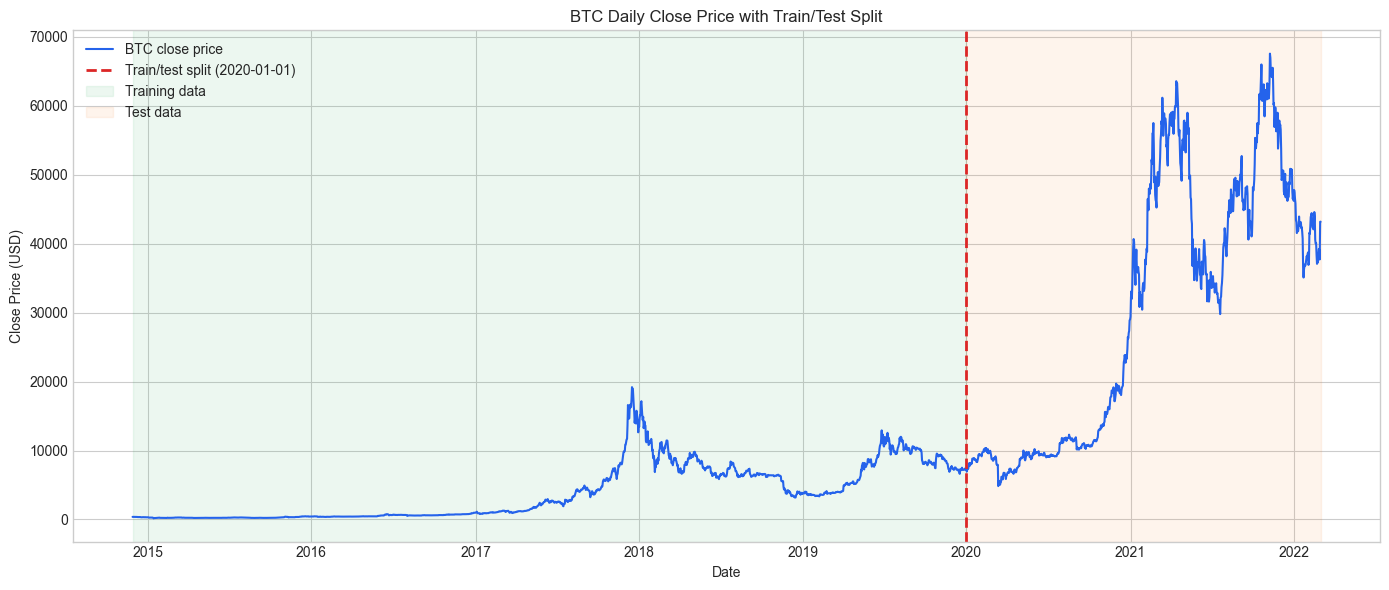

In [5]:
# Price trend visualisation: mark the train/test split point
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(price_data.index, price_data["close"], label="BTC close price", color="#2563eb", linewidth=1.5)
ax.axvline(SPLIT_DATE, color="#dc2626", linestyle="--", linewidth=2, label="Train/test split (2020-01-01)")

ax.axvspan(price_data.index.min(), SPLIT_DATE, color="#16a34a", alpha=0.08, label="Training data")
ax.axvspan(SPLIT_DATE, price_data.index.max(), color="#f97316", alpha=0.08, label="Test data")

ax.set_title("BTC Daily Close Price with Train/Test Split")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (USD)")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

## 2. Bot Building Blocks (WMA Filters)

This section implements the core building blocks of the Trading Bot: padding, the Weighted Moving Average (WMA) convolution framework, the SMA/LMA/EMA filters, and crossover-based buy/sell signal detection.

### 2.1 Padding and WMA Framework

In [6]:
def pad(P, N):
    """Pad a price series by flipping the first N-1 interior values."""
    P = np.asarray(P, dtype=float)
    if N < 1:
        raise ValueError("N must be at least 1")
    if len(P) <= N:
        raise ValueError("Price series must contain more values than N")

    padding = -np.flip(P[1:N])
    return np.append(padding, P)


def wma(P, N, kernel):
    """Compute a weighted moving average by convolving a padded price series."""
    P = np.asarray(P, dtype=float)
    kernel = np.asarray(kernel, dtype=float)
    if len(kernel) != N:
        raise ValueError("Kernel length must match N")
    return np.convolve(pad(P, N), kernel, mode="valid")

### 2.2 SMA, LMA, and EMA Filters

The three filters correspond to the Simple Moving Average (SMA), Linear-Weighted Moving Average (LMA), and Exponential Moving Average (EMA). The EMA is implemented as a finite-window truncated version.

In [7]:
def sma_filter(N):
    """Return a Simple Moving Average filter."""
    if N < 1:
        raise ValueError("N must be at least 1")
    return np.ones(N, dtype=float) / N


def lma_filter(N):
    """Return a Linear-Weighted Moving Average filter."""
    if N < 1:
        raise ValueError("N must be at least 1")
    k = np.arange(N, dtype=float)
    weights = 1 - k * (1.0 / N)
    return weights * (2.0 / (N + 1))


def ema_filter(N, alpha):
    """Return a finite-window Exponential Moving Average filter."""
    if N < 1:
        raise ValueError("N must be at least 1")
    if not 0 < alpha < 1:
        raise ValueError("alpha must be between 0 and 1")
    k = np.arange(N, dtype=float)
    weights = (1 - alpha) ** k
    return weights * alpha

In [8]:
# Validate filter shapes, sums, monotonicity, and WMA output length
validation_prices = train_data[:120]
validation_window = 20
validation_alpha = 0.30

sma_kernel = sma_filter(validation_window)
lma_kernel = lma_filter(validation_window)
ema_kernel = ema_filter(validation_window, validation_alpha)

assert len(sma_kernel) == validation_window
assert len(lma_kernel) == validation_window
assert len(ema_kernel) == validation_window
assert np.isclose(sma_kernel.sum(), 1.0)
assert np.isclose(lma_kernel.sum(), 1.0)
assert np.all(np.diff(lma_kernel) < 0)
assert np.all(np.diff(ema_kernel) < 0)

for kernel in [sma_kernel, lma_kernel, ema_kernel]:
    filtered = wma(validation_prices, validation_window, kernel)
    assert len(filtered) == len(validation_prices)

print("Filter validation passed.")
print(f"SMA filter sum: {sma_kernel.sum():.6f}")
print(f"LMA filter sum: {lma_kernel.sum():.6f}")
print(f"EMA finite-window sum: {ema_kernel.sum():.6f}")
print(f"WMA output length: {len(filtered)} values")

Filter validation passed.
SMA filter sum: 1.000000
LMA filter sum: 1.000000
EMA finite-window sum: 0.999202
WMA output length: 120 values


This cell checks the basic properties of the SMA, LMA, and EMA filters, including weight sums, filter lengths, and output lengths.

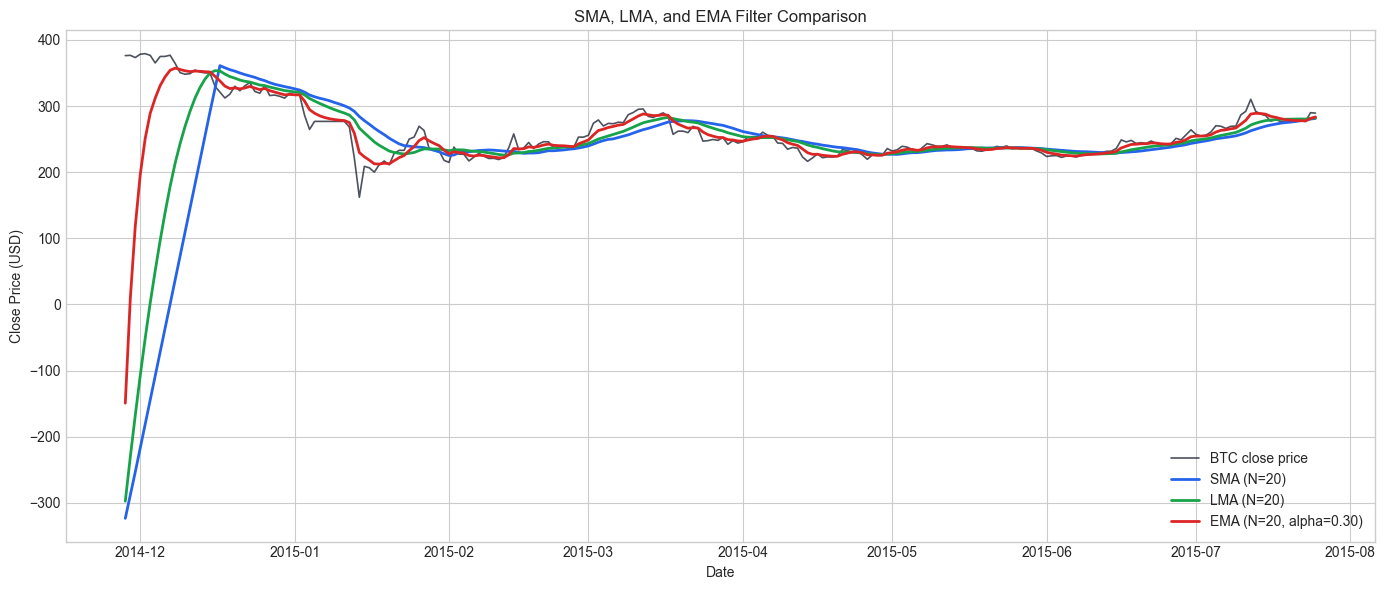

In [9]:
# Visual comparison of SMA, LMA, and EMA on the training price series
plot_points = 240
plot_prices = train_data[:plot_points]
plot_dates = train_prices.index[:plot_points]
window = 20
alpha = 0.30

sma_signal = wma(plot_prices, window, sma_filter(window))
lma_signal = wma(plot_prices, window, lma_filter(window))
ema_signal = wma(plot_prices, window, ema_filter(window, alpha))

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(plot_dates, plot_prices, label="BTC close price", color="#111827", linewidth=1.2, alpha=0.75)
ax.plot(plot_dates, sma_signal, label="SMA (N=20)", color="#2563eb", linewidth=2)
ax.plot(plot_dates, lma_signal, label="LMA (N=20)", color="#16a34a", linewidth=2)
ax.plot(plot_dates, ema_signal, label="EMA (N=20, alpha=0.30)", color="#dc2626", linewidth=2)

ax.set_title("SMA, LMA, and EMA Filter Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (USD)")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

This figure compares the three WMA filters on the same segment of training prices. SMA is smoother, EMA responds faster, and LMA sits between the two.

### 2.3 Crossover Signal Detection

A short-term signal crossing above a long-term signal corresponds to a buy signal, while crossing below it corresponds to a sell signal. This section first implements a generic crossover detection function, which is later connected to the 14-dimensional Bot and the backtesting engine.

In [10]:
def sign_change_filter():
    """Return a simple sign-change filter from the project specification."""
    return np.array([0.5, -0.5], dtype=float)


def detect_buy_sell_signals(diff_signal):
    """Detect buy and sell indices from the difference between two signals.

    A buy signal occurs when the difference changes from negative to positive.
    A sell signal occurs when the difference changes from positive to negative.
    """
    diff_signal = np.asarray(diff_signal, dtype=float)
    sign_signal = np.sign(diff_signal)
    changes = np.diff(sign_signal)
    buy_indices = np.where(changes > 0)[0] + 1
    sell_indices = np.where(changes < 0)[0] + 1
    return buy_indices, sell_indices

In [11]:
# Validate crossover detection with a simple SMA(10) vs SMA(40) example
example_points = 720
example_prices = train_data[:example_points]
example_dates = train_prices.index[:example_points]

short_window = 10
long_window = 40
short_signal = wma(example_prices, short_window, sma_filter(short_window))
long_signal = wma(example_prices, long_window, sma_filter(long_window))
diff_signal = short_signal - long_signal
buy_indices, sell_indices = detect_buy_sell_signals(diff_signal)

assert len(short_signal) == len(example_prices)
assert len(long_signal) == len(example_prices)
assert len(buy_indices) > 0
assert len(sell_indices) > 0

print("Crossover validation passed.")
print(f"Buy signals detected: {len(buy_indices)}")
print(f"Sell signals detected: {len(sell_indices)}")
print(f"First five buy indices: {buy_indices[:5].tolist()}")
print(f"First five sell indices: {sell_indices[:5].tolist()}")

Crossover validation passed.
Buy signals detected: 8
Sell signals detected: 8
First five buy indices: [82, 162, 201, 303, 447]
First five sell indices: [38, 118, 185, 254, 414]


This cell uses SMA(10) and SMA(40) as a simple example to check whether the crossover detection logic can identify reasonable buy/sell signals.

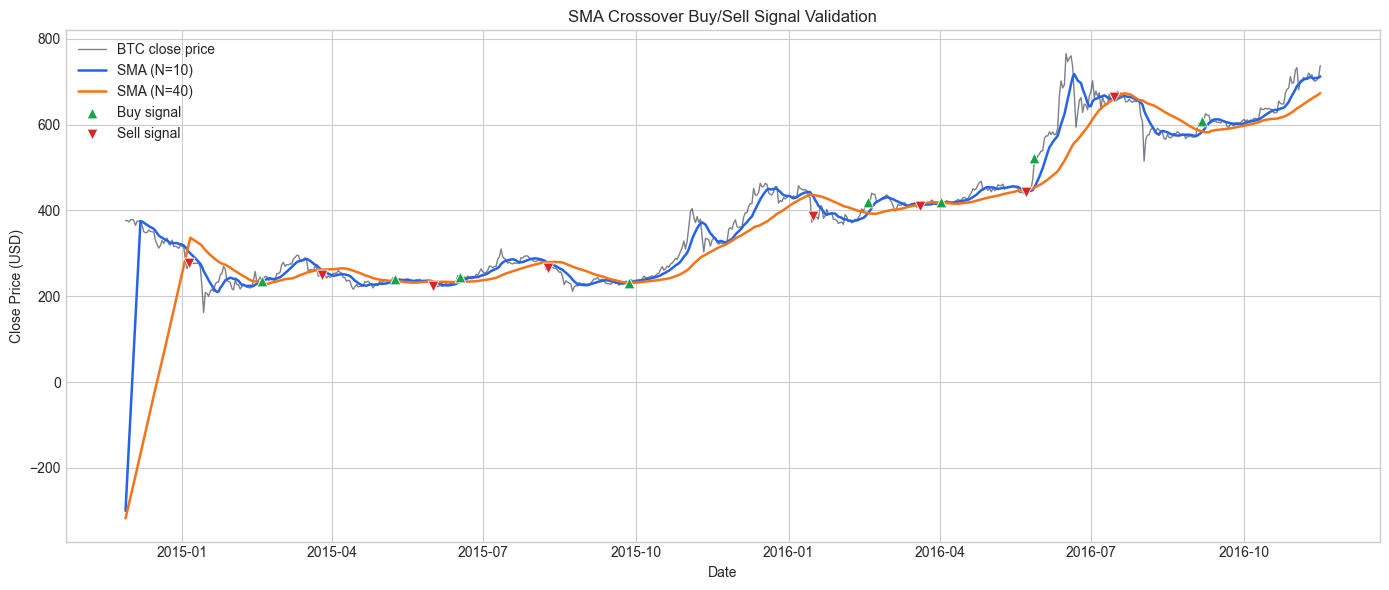

In [12]:
# Visual validation of crossover buy/sell signals
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(example_dates, example_prices, label="BTC close price", color="#111827", linewidth=1.0, alpha=0.55)
ax.plot(example_dates, short_signal, label="SMA (N=10)", color="#2563eb", linewidth=1.8)
ax.plot(example_dates, long_signal, label="SMA (N=40)", color="#f97316", linewidth=1.8)

ax.scatter(example_dates[buy_indices], example_prices[buy_indices], marker="^", s=60,
           color="#16a34a", edgecolor="white", linewidth=0.6, label="Buy signal", zorder=5)
ax.scatter(example_dates[sell_indices], example_prices[sell_indices], marker="v", s=60,
           color="#dc2626", edgecolor="white", linewidth=0.6, label="Sell signal", zorder=5)

ax.set_title("SMA Crossover Buy/Sell Signal Validation")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (USD)")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

After plotting the crossover signals on the price curve, the buy and sell points can be visually checked against the expected locations.

## 3. Bot Architecture & Parameterisation

This section implements two Trading Bot structures. The first is the 14-dimensional compound-signal Bot used in the main experiment, where both HIGH and LOW are weighted combinations of SMA, LMA, and EMA. The second is a 2-dimensional simple Bot that uses only a short-term SMA and a long-term SMA crossover, which is later used to compare the search difficulty of low-dimensional and high-dimensional parameter spaces.

### 3.1 14-Dimensional Compound Bot

The parameter vector `x` is ordered as `[w1, w2, w3, d1, d2, d3, alpha1, w4, w5, w6, d4, d5, d6, alpha2]`. The weights `w` control each filter's contribution, `d` is the duration/window size, and `alpha` is the EMA decay parameter.

In [13]:
PARAM_BOUNDS = [
    (0.0, 1.0),   # w1: SMA weight for HIGH
    (0.0, 1.0),   # w2: LMA weight for HIGH
    (0.0, 1.0),   # w3: EMA weight for HIGH
    (2, 50),      # d1: SMA window for HIGH
    (2, 50),      # d2: LMA window for HIGH
    (2, 50),      # d3: EMA window for HIGH
    (0.01, 0.99), # alpha1: EMA decay for HIGH
    (0.0, 1.0),   # w4: SMA weight for LOW
    (0.0, 1.0),   # w5: LMA weight for LOW
    (0.0, 1.0),   # w6: EMA weight for LOW
    (2, 100),     # d4: SMA window for LOW
    (2, 100),     # d5: LMA window for LOW
    (2, 100),     # d6: EMA window for LOW
    (0.01, 0.99), # alpha2: EMA decay for LOW
]

DIM = 14
DURATION_INDICES = [3, 4, 5, 10, 11, 12]
BOUNDS_LOW = np.array([lo for lo, _ in PARAM_BOUNDS], dtype=float)
BOUNDS_HIGH = np.array([hi for _, hi in PARAM_BOUNDS], dtype=float)


def clip_solution(x):
    """Clip a 14-dimensional solution to the legal parameter bounds."""
    x_clipped = np.asarray(x, dtype=float).copy()
    x_clipped = np.clip(x_clipped, BOUNDS_LOW, BOUNDS_HIGH)
    for idx in DURATION_INDICES:
        x_clipped[idx] = int(round(x_clipped[idx]))
    return x_clipped


def random_solution():
    """Generate a random 14-dimensional solution inside the parameter bounds."""
    x = np.array([np.random.uniform(lo, hi) for lo, hi in PARAM_BOUNDS], dtype=float)
    return clip_solution(x)

In [14]:
def build_signals(P, x):
    """Build HIGH and LOW signals from a 14-dimensional bot parameter vector."""
    P = np.asarray(P, dtype=float)
    x = clip_solution(x)

    w1, w2, w3 = x[0], x[1], x[2]
    d1, d2, d3 = int(x[3]), int(x[4]), int(x[5])
    alpha1 = x[6]
    w4, w5, w6 = x[7], x[8], x[9]
    d4, d5, d6 = int(x[10]), int(x[11]), int(x[12])
    alpha2 = x[13]

    sma_high = wma(P, d1, sma_filter(d1))
    lma_high = wma(P, d2, lma_filter(d2))
    ema_high = wma(P, d3, ema_filter(d3, alpha1))

    high_weight_sum = w1 + w2 + w3
    if high_weight_sum < 1e-10:
        high_weight_sum = 1.0
    high_signal = (w1 * sma_high + w2 * lma_high + w3 * ema_high) / high_weight_sum

    sma_low = wma(P, d4, sma_filter(d4))
    lma_low = wma(P, d5, lma_filter(d5))
    ema_low = wma(P, d6, ema_filter(d6, alpha2))

    low_weight_sum = w4 + w5 + w6
    if low_weight_sum < 1e-10:
        low_weight_sum = 1.0
    low_signal = (w4 * sma_low + w5 * lma_low + w6 * ema_low) / low_weight_sum

    return high_signal, low_signal

In [15]:
# Validate 14-dimensional signal construction
example_14d_solution = np.array([
    1.0, 0.0, 0.0, 10, 20, 20, 0.30,
    1.0, 0.0, 0.0, 40, 40, 40, 0.30,
])
example_high, example_low = build_signals(train_data, example_14d_solution)

assert len(example_high) == len(train_data)
assert len(example_low) == len(train_data)
assert np.all(np.isfinite(example_high))
assert np.all(np.isfinite(example_low))

print("14D bot signal validation passed.")
print(f"HIGH signal length: {len(example_high)}")
print(f"LOW signal length: {len(example_low)}")

14D bot signal validation passed.
HIGH signal length: 1860
LOW signal length: 1860


This cell runs a trial 14-dimensional parameter vector to confirm that the HIGH and LOW signals can be generated from the full parameter vector.

### 3.2 2-Dimensional Simple SMA Bot

The simple Bot contains only two parameters: the short-term SMA window `N1` and the long-term SMA window `N2`. It serves as the low-dimensional control group for analysing whether the larger hypothesis space of the high-dimensional Bot is worth the additional search cost.

In [16]:
SIMPLE_PARAM_BOUNDS = [
    (2, 50),    # N1: short-term SMA window
    (10, 200),  # N2: long-term SMA window
]

SIMPLE_DIM = 2
SIMPLE_BOUNDS_LOW = np.array([lo for lo, _ in SIMPLE_PARAM_BOUNDS], dtype=float)
SIMPLE_BOUNDS_HIGH = np.array([hi for _, hi in SIMPLE_PARAM_BOUNDS], dtype=float)


def clip_simple_solution(x):
    """Clip a 2-dimensional simple-bot solution to legal bounds."""
    x_clipped = np.asarray(x, dtype=float).copy()
    x_clipped = np.clip(x_clipped, SIMPLE_BOUNDS_LOW, SIMPLE_BOUNDS_HIGH)
    return np.array([int(round(x_clipped[0])), int(round(x_clipped[1]))], dtype=float)


def random_simple_solution():
    """Generate a random 2-dimensional simple-bot solution."""
    x = np.array([np.random.uniform(lo, hi) for lo, hi in SIMPLE_PARAM_BOUNDS], dtype=float)
    return clip_simple_solution(x)


def build_simple_signals(P, x):
    """Build short-term and long-term SMA signals for the simple bot."""
    P = np.asarray(P, dtype=float)
    x = clip_simple_solution(x)
    n1, n2 = int(x[0]), int(x[1])
    high_signal = wma(P, n1, sma_filter(n1))
    low_signal = wma(P, n2, sma_filter(n2))
    return high_signal, low_signal

In [17]:
# Validate 2-dimensional simple bot signal construction
simple_example_solution = np.array([10, 40])
simple_high, simple_low = build_simple_signals(train_data, simple_example_solution)

assert len(simple_high) == len(train_data)
assert len(simple_low) == len(train_data)
assert np.all(np.isfinite(simple_high))
assert np.all(np.isfinite(simple_low))

print("Simple bot signal validation passed.")
print(f"Short SMA length: {len(simple_high)}")
print(f"Long SMA length: {len(simple_low)}")

Simple bot signal validation passed.
Short SMA length: 1860
Long SMA length: 1860


This cell checks whether the short-term and long-term signals of the 2-dimensional Simple SMA Bot can be generated correctly. It is later used as the low-dimensional control group for comparing the simple search space with the 14-dimensional compound space.

## 4. Fitness Evaluation Function

This section implements the Fitness Function and the Backtesting Engine.

In [18]:
INITIAL_CASH = 1000.0
FEE_RATE = 0.03


def backtest_signals(P, high_signal, low_signal, return_trades=False):
    """Backtest a crossover strategy and return final cash fitness."""
    P = np.asarray(P, dtype=float)
    high_signal = np.asarray(high_signal, dtype=float)
    low_signal = np.asarray(low_signal, dtype=float)

    if len(P) != len(high_signal) or len(P) != len(low_signal):
        raise ValueError("Price and signal arrays must have the same length")
    if len(P) == 0:
        raise ValueError("Price series must not be empty")

    diff = high_signal - low_signal
    buy_indices, sell_indices = detect_buy_sell_signals(diff)

    trades = []
    for idx in buy_indices:
        if idx < len(P):
            trades.append((int(idx), "buy"))
    for idx in sell_indices:
        if idx < len(P):
            trades.append((int(idx), "sell"))
    trades.sort(key=lambda item: item[0])

    cash = INITIAL_CASH
    btc = 0.0
    holding_btc = False
    executed_trades = []

    for idx, action in trades:
        price = P[idx]
        if action == "buy" and not holding_btc:
            btc = cash * (1 - FEE_RATE) / price
            cash = 0.0
            holding_btc = True
            executed_trades.append({"index": idx, "action": action, "price": price, "cash": cash, "btc": btc})
        elif action == "sell" and holding_btc:
            cash = btc * price * (1 - FEE_RATE)
            btc = 0.0
            holding_btc = False
            executed_trades.append({"index": idx, "action": action, "price": price, "cash": cash, "btc": btc})

    if holding_btc:
        final_idx = len(P) - 1
        cash = btc * P[final_idx] * (1 - FEE_RATE)
        btc = 0.0
        holding_btc = False
        executed_trades.append({"index": final_idx, "action": "final_sell", "price": P[final_idx], "cash": cash, "btc": btc})

    if return_trades:
        return cash, executed_trades
    return cash


def evaluate_bot(P, x, return_trades=False):
    """Evaluate the 14-dimensional compound bot on a price series."""
    try:
        high_signal, low_signal = build_signals(P, x)
        return backtest_signals(P, high_signal, low_signal, return_trades=return_trades)
    except Exception:
        if return_trades:
            return INITIAL_CASH, []
        return INITIAL_CASH


def evaluate_simple_bot(P, x, return_trades=False):
    """Evaluate the 2-dimensional simple SMA crossover bot on a price series."""
    try:
        high_signal, low_signal = build_simple_signals(P, x)
        return backtest_signals(P, high_signal, low_signal, return_trades=return_trades)
    except Exception:
        if return_trades:
            return INITIAL_CASH, []
        return INITIAL_CASH

In [19]:
# Fitness sanity check using known SMA(10) vs SMA(40) parameters
sma_10_40_14d = np.array([
    1.0, 0.0, 0.0, 10, 20, 20, 0.30,
    1.0, 0.0, 0.0, 40, 40, 40, 0.30,
])
sma_10_40_simple = np.array([10, 40])

train_fitness_14d, train_trades_14d = evaluate_bot(train_data, sma_10_40_14d, return_trades=True)
test_fitness_14d, test_trades_14d = evaluate_bot(test_data, sma_10_40_14d, return_trades=True)
train_fitness_simple, train_trades_simple = evaluate_simple_bot(train_data, sma_10_40_simple, return_trades=True)
test_fitness_simple, test_trades_simple = evaluate_simple_bot(test_data, sma_10_40_simple, return_trades=True)

assert np.isclose(train_fitness_14d, train_fitness_simple)
assert np.isclose(test_fitness_14d, test_fitness_simple)
assert train_fitness_14d > 0
assert test_fitness_14d > 0

print("Fitness validation passed.")
print(f"14D SMA(10,40) train fitness: ${train_fitness_14d:.2f}")
print(f"14D SMA(10,40) test fitness: ${test_fitness_14d:.2f}")
print(f"Simple SMA(10,40) train fitness: ${train_fitness_simple:.2f}")
print(f"Simple SMA(10,40) test fitness: ${test_fitness_simple:.2f}")
print(f"Train executed trades: {len(train_trades_14d)}")
print(f"Test executed trades: {len(test_trades_14d)}")

Fitness validation passed.
14D SMA(10,40) train fitness: $10576.12
14D SMA(10,40) test fitness: $3938.82
Simple SMA(10,40) train fitness: $10576.12
Simple SMA(10,40) test fitness: $3938.82
Train executed trades: 46
Test executed trades: 16


This step checks the fitness evaluation using a known set of SMA parameters. The trade count, final cash, and fitness are all returned correctly, confirming that the fee, all-in trading, and final liquidation rules are connected.

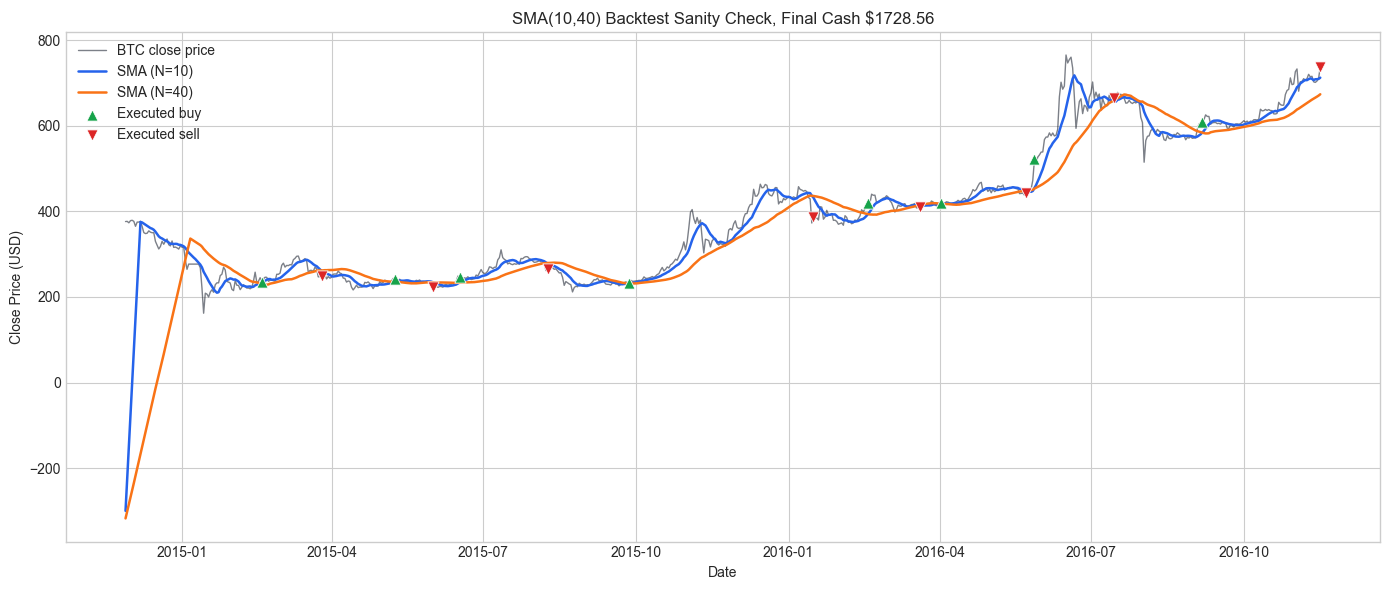

In [20]:
# Visual sanity check for the SMA(10,40) backtest on training data
visual_points = 720
visual_prices = train_data[:visual_points]
visual_dates = train_prices.index[:visual_points]
visual_high, visual_low = build_simple_signals(visual_prices, sma_10_40_simple)
visual_fitness, visual_trades = evaluate_simple_bot(visual_prices, sma_10_40_simple, return_trades=True)

buy_trade_indices = [trade["index"] for trade in visual_trades if trade["action"] == "buy"]
sell_trade_indices = [trade["index"] for trade in visual_trades if trade["action"] in ["sell", "final_sell"]]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(visual_dates, visual_prices, label="BTC close price", color="#111827", linewidth=1.0, alpha=0.55)
ax.plot(visual_dates, visual_high, label="SMA (N=10)", color="#2563eb", linewidth=1.8)
ax.plot(visual_dates, visual_low, label="SMA (N=40)", color="#f97316", linewidth=1.8)

if buy_trade_indices:
    ax.scatter(visual_dates[buy_trade_indices], visual_prices[buy_trade_indices], marker="^", s=65,
               color="#16a34a", edgecolor="white", linewidth=0.6, label="Executed buy", zorder=5)
if sell_trade_indices:
    ax.scatter(visual_dates[sell_trade_indices], visual_prices[sell_trade_indices], marker="v", s=65,
               color="#dc2626", edgecolor="white", linewidth=0.6, label="Executed sell", zorder=5)

ax.set_title(f"SMA(10,40) Backtest Sanity Check, Final Cash ${visual_fitness:.2f}")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (USD)")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

This figure shows the example strategy's buy/sell points together with its equity curve. It helps confirm that trade execution and capital changes in the backtest match the stated rules.

## 5. Optimisation Helper Functions

This section keeps the shared population evaluation helper used by all optimisation algorithms.

In [21]:
def evaluate_population(P, population, evaluator=evaluate_bot):
    """Evaluate every individual in a population."""
    return np.array([evaluator(P, individual) for individual in population], dtype=float)

## 6. Algorithm 1: Whale Optimisation Algorithm (WOA)

This section implements the Whale Optimisation Algorithm (WOA) proposed by Mirjalili and Lewis from scratch. The algorithm switches between encircling prey, searching for prey, and spiral updating, using the current global best solution to guide the search.

In [22]:
def whale_optimisation_algorithm(P, n_whales=50, max_iter=100, verbose=True):
    """Optimise the 14-dimensional bot with the Whale Optimisation Algorithm."""
    if n_whales < 2:
        raise ValueError("n_whales must be at least 2")
    if max_iter < 1:
        raise ValueError("max_iter must be at least 1")

    # Each whale is a 14-dimensional Bot parameter vector, initialised randomly within the valid bounds.
    whales = np.array([random_solution() for _ in range(n_whales)], dtype=float)
    fitness_values = evaluate_population(P, whales)
    eval_count = n_whales

    # WOA uses the current global-best whale X* as the prey position, and all updates are built around it.
    best_index = int(np.argmax(fitness_values))
    best_solution = whales[best_index].copy()
    best_fitness = float(fitness_values[best_index])
    fitness_history = [best_fitness]
    eval_count_history = [eval_count]

    # b controls the shape of the spiral update and is usually set to 1 in standard WOA.
    b = 1.0
    if verbose:
        print(f"WOA initial best fitness: ${best_fitness:.2f}")

    for iteration in range(max_iter):
        # a decreases linearly from 2 to 0: early iterations make |A| more likely to exceed 1 for exploration, while later iterations favour encircling the best solution.
        a = 2.0 - 2.0 * (iteration / max_iter)
        updated_whales = whales.copy()

        for i in range(n_whales):
            # p decides whether this update uses shrinking encircling/random search or the spiral attacking mechanism.
            p = np.random.random()

            if p < 0.5:
                # r is a dimension-wise random vector, giving each parameter dimension a different search step size.
                r = np.random.random(DIM)
                # A controls movement direction and strength; C randomly scales the target position to increase perturbation.
                A = 2.0 * a * r - a
                C = 2.0 * r

                if np.max(np.abs(A)) < 1.0:
                    # When |A|<1, perform encircling prey: shrink the search around the current best X*.
                    distance = np.abs(C * best_solution - whales[i])
                    updated_whales[i] = best_solution - A * distance
                else:
                    # When |A|>=1, perform search for prey: follow a random whale to reduce premature convergence around a local optimum.
                    random_index = np.random.randint(n_whales)
                    random_whale = whales[random_index]
                    distance = np.abs(C * random_whale - whales[i])
                    updated_whales[i] = random_whale - A * distance
            else:
                # l controls the spiral phase; positive and negative values move the whale around X* along a logarithmic spiral.
                l = np.random.uniform(-1.0, 1.0)
                distance_to_best = np.abs(best_solution - whales[i])
                # Spiral updating: D*exp(b*l)*cos(2*pi*l)+X*, modelling bubble-net spiral feeding.
                updated_whales[i] = distance_to_best * np.exp(b * l) * np.cos(2 * np.pi * l) + best_solution

            # Clip after every position update to keep alpha, weights, and window lengths within bounds.
            updated_whales[i] = clip_solution(updated_whales[i])

        whales = updated_whales
        # Each whale produces one new candidate solution per iteration, so the evaluation count increases by n_whales.
        fitness_values = evaluate_population(P, whales)
        eval_count += n_whales

        iteration_best_index = int(np.argmax(fitness_values))
        iteration_best_fitness = float(fitness_values[iteration_best_index])
        # Update X* so all whales use the new best position as the prey reference in the next iteration.
        if iteration_best_fitness > best_fitness:
            best_fitness = iteration_best_fitness
            best_solution = whales[iteration_best_index].copy()

        fitness_history.append(best_fitness)
        eval_count_history.append(eval_count)

        if verbose:
            print(
                f"WOA iteration {iteration + 1:03d}/{max_iter}, "
                f"best fitness: ${best_fitness:.2f}, evaluations: {eval_count}"
            )

    return best_solution, best_fitness, fitness_history, eval_count_history

In [23]:
# Quick WOA smoke test required for this stage
np.random.seed(RANDOM_SEED)

woa_quick_solution, woa_quick_fitness, woa_quick_history, woa_quick_evals = whale_optimisation_algorithm(
    train_data,
    n_whales=10,
    max_iter=5,
    verbose=True,
)

assert len(woa_quick_solution) == DIM
assert len(woa_quick_history) == 6
assert len(woa_quick_evals) == 6
assert woa_quick_evals[-1] == 60
assert np.isfinite(woa_quick_fitness)
assert woa_quick_fitness > 0

print("WOA quick test passed.")
print(f"WOA quick best fitness: ${woa_quick_fitness:.2f}")
print(f"WOA quick evaluation count: {woa_quick_evals[-1]}")
print(f"WOA quick best solution: {np.round(woa_quick_solution, 4).tolist()}")

WOA initial best fitness: $10190.16
WOA iteration 001/5, best fitness: $17988.29, evaluations: 20
WOA iteration 002/5, best fitness: $19191.09, evaluations: 30
WOA iteration 003/5, best fitness: $19191.09, evaluations: 40
WOA iteration 004/5, best fitness: $21605.89, evaluations: 50
WOA iteration 005/5, best fitness: $21605.89, evaluations: 60
WOA quick test passed.
WOA quick best fitness: $21605.89
WOA quick evaluation count: 60
WOA quick best solution: [0.3459, 0.0, 0.0, 27.0, 2.0, 9.0, 0.01, 0.2871, 0.1901, 0.6318, 11.0, 78.0, 2.0, 0.2966]


The WOA quick test successfully returns the best solution, best fitness, and convergence record. This mainly verifies that the algorithm flow is connected to the evaluator, rather than serving as the final experimental conclusion.

## 7. Algorithm 2: Particle Swarm Optimisation (PSO) and Random Search

This section implements the original 1995 Particle Swarm Optimisation (PSO) by Kennedy and Eberhart from scratch, using `Vmax` to clip velocity dimension by dimension. It then implements the Random Search baseline as the random-search control.

In [24]:
def particle_swarm_optimisation(P, n_particles=50, max_iter=100,
                                 c1=2.0, c2=2.0, vmax_fraction=0.3,
                                 verbose=True):
    """Optimise the 14-dimensional bot with original PSO without inertia weight."""
    if n_particles < 2:
        raise ValueError("n_particles must be at least 2")
    if max_iter < 1:
        raise ValueError("max_iter must be at least 1")
    if vmax_fraction <= 0:
        raise ValueError("vmax_fraction must be positive")

    # Particle positions are Bot parameters; all positions are randomly initialised within the valid search space.
    positions = np.array([random_solution() for _ in range(n_particles)], dtype=float)
    # Vmax is a fixed fraction of each dimension's search range and is used for velocity clamping in original PSO.
    vmax = vmax_fraction * (BOUNDS_HIGH - BOUNDS_LOW)
    # Initial velocities can move in positive or negative directions, but their magnitudes are capped by Vmax to avoid jumping outside the bounds immediately.
    velocities = np.random.uniform(-vmax, vmax, size=(n_particles, DIM))

    fitness_values = evaluate_population(P, positions)
    eval_count = n_particles

    # pbest stores the best position each particle has visited so far.
    personal_best_positions = positions.copy()
    personal_best_fitness = fitness_values.copy()

    # gbest stores the best position found by the whole swarm so far and is the target of the social learning term.
    best_index = int(np.argmax(personal_best_fitness))
    global_best_position = personal_best_positions[best_index].copy()
    global_best_fitness = float(personal_best_fitness[best_index])
    fitness_history = [global_best_fitness]
    eval_count_history = [eval_count]

    if verbose:
        print(f"PSO initial best fitness: ${global_best_fitness:.2f}")

    for iteration in range(1, max_iter + 1):
        for i in range(n_particles):
            # r1 and r2 are dimension-wise random weights that add stochastic exploration to the cognitive and social terms.
            r1 = np.random.random(DIM)
            r2 = np.random.random(DIM)
            # The cognitive term pulls the particle back toward its own historical best position, pbest.
            cognitive = c1 * r1 * (personal_best_positions[i] - positions[i])
            # The social term pulls the particle toward the swarm's historical best position, gbest.
            social = c2 * r2 * (global_best_position - positions[i])
            # New velocity = old velocity + cognitive + social.
            velocities[i] = velocities[i] + cognitive + social
            # Prevent large jumps from destabilising the search.
            velocities[i] = np.clip(velocities[i], -vmax, vmax)
            # Move the position forward by its velocity; clip_solution handles both bounds and integer rounding for window lengths.
            positions[i] = clip_solution(positions[i] + velocities[i])

        fitness_values = evaluate_population(P, positions)
        eval_count += n_particles

        # Update pbest only when the current position improves on the personal historical best, preserving each particle's best experience.
        improved = fitness_values > personal_best_fitness
        personal_best_positions[improved] = positions[improved]
        personal_best_fitness[improved] = fitness_values[improved]

        # Select gbest from all pbest values rather than only current positions, preserving best-so-far monotonicity.
        best_index = int(np.argmax(personal_best_fitness))
        if personal_best_fitness[best_index] > global_best_fitness:
            global_best_fitness = float(personal_best_fitness[best_index])
            global_best_position = personal_best_positions[best_index].copy()

        fitness_history.append(global_best_fitness)
        eval_count_history.append(eval_count)

        if verbose:
            print(
                f"PSO iteration {iteration:03d}/{max_iter}, "
                f"best fitness: ${global_best_fitness:.2f}, evaluations: {eval_count}"
            )

    return global_best_position, global_best_fitness, fitness_history, eval_count_history

In [25]:
def random_search(P, max_evaluations=5000, verbose=True):
    """Uniform random search baseline over the 14-dimensional parameter space."""
    if max_evaluations < 1:
        raise ValueError("max_evaluations must be at least 1")

    best_solution = random_solution()
    best_fitness = float(evaluate_bot(P, best_solution))
    fitness_history = [best_fitness]
    eval_count_history = [1]

    if verbose:
        print(f"Random Search initial best fitness: ${best_fitness:.2f}")

    for evaluation in range(2, max_evaluations + 1):
        candidate = random_solution()
        candidate_fitness = float(evaluate_bot(P, candidate))
        if candidate_fitness > best_fitness:
            best_fitness = candidate_fitness
            best_solution = candidate.copy()

        fitness_history.append(best_fitness)
        eval_count_history.append(evaluation)

        if verbose and (evaluation == max_evaluations or evaluation % 10 == 0):
            print(
                f"Random Search evaluation {evaluation:04d}/{max_evaluations}, "
                f"best fitness: ${best_fitness:.2f}"
            )

    return best_solution, best_fitness, fitness_history, eval_count_history

In [26]:
# Quick PSO and Random Search smoke tests required for this stage
np.random.seed(RANDOM_SEED)

pso_quick_solution, pso_quick_fitness, pso_quick_history, pso_quick_evals = particle_swarm_optimisation(
    train_data,
    n_particles=10,
    max_iter=5,
    c1=2.0,
    c2=2.0,
    vmax_fraction=0.3,
    verbose=True,
)

np.random.seed(RANDOM_SEED)
random_quick_solution, random_quick_fitness, random_quick_history, random_quick_evals = random_search(
    train_data,
    max_evaluations=60,
    verbose=True,
)

assert len(pso_quick_solution) == DIM
assert len(pso_quick_history) == 6
assert len(pso_quick_evals) == 6
assert pso_quick_evals[-1] == 60
assert np.isfinite(pso_quick_fitness)
assert pso_quick_fitness > 0

assert len(random_quick_solution) == DIM
assert len(random_quick_history) == 60
assert len(random_quick_evals) == 60
assert random_quick_evals[-1] == 60
assert np.isfinite(random_quick_fitness)
assert random_quick_fitness > 0

print("PSO quick test passed.")
print(f"PSO quick best fitness: ${pso_quick_fitness:.2f}")
print(f"PSO quick evaluation count: {pso_quick_evals[-1]}")
print(f"PSO quick best solution: {np.round(pso_quick_solution, 4).tolist()}")
print("Random Search quick test passed.")
print(f"Random Search quick best fitness: ${random_quick_fitness:.2f}")
print(f"Random Search quick evaluation count: {random_quick_evals[-1]}")
print(f"Random Search quick best solution: {np.round(random_quick_solution, 4).tolist()}")

PSO initial best fitness: $10190.16
PSO iteration 001/5, best fitness: $10190.16, evaluations: 20


PSO iteration 002/5, best fitness: $18944.57, evaluations: 30
PSO iteration 003/5, best fitness: $18944.57, evaluations: 40
PSO iteration 004/5, best fitness: $18944.57, evaluations: 50
PSO iteration 005/5, best fitness: $18944.57, evaluations: 60
Random Search initial best fitness: $694.60
Random Search evaluation 0010/60, best fitness: $10190.16
Random Search evaluation 0020/60, best fitness: $12472.85
Random Search evaluation 0030/60, best fitness: $20437.28
Random Search evaluation 0040/60, best fitness: $20437.28
Random Search evaluation 0050/60, best fitness: $20437.28
Random Search evaluation 0060/60, best fitness: $20437.28
PSO quick test passed.
PSO quick best fitness: $18944.57
PSO quick evaluation count: 60
PSO quick best solution: [0.5868, 0.0, 0.4572, 25.0, 14.0, 20.0, 0.6718, 0.1134, 0.3391, 0.3676, 38.0, 100.0, 23.0, 0.5875]
Random Search quick test passed.
Random Search quick best fitness: $20437.28
Random Search quick evaluation count: 60
Random Search quick best solut

## 8. Experiments & Comparison

This section runs the full set of experiments. Experiment A uses the 14-dimensional compound-signal Bot and performs five independent runs for WOA, PSO, and Random Search. Experiment B uses the 2-dimensional Simple SMA Bot and performs five independent runs for WOA and PSO. Experiment C runs a PSO population size sensitivity analysis while keeping the total number of fitness evaluations fixed. Finally, the Buy-and-Hold baseline is calculated.

In [27]:
import pickle
import time

POP_SIZE = 50
MAX_EVALUATIONS = 5000
MAX_ITER = MAX_EVALUATIONS // POP_SIZE
N_RUNS = 5
SEEDS = [42, 123, 456, 789, 1024]
POP_SIZES_TO_TEST = [20, 50, 100]

RESULTS_PATH = OUTPUT_DIR / "experiment_results.pkl"
SUMMARY_PATH = OUTPUT_DIR / "experiment_summary.csv"

print(f"Population size: {POP_SIZE}")
print(f"Max evaluations per run: {MAX_EVALUATIONS}")
print(f"Max iterations per population-based run: {MAX_ITER}")
print(f"Independent runs: {N_RUNS}")
print(f"Seeds: {SEEDS}")

Population size: 50
Max evaluations per run: 5000
Max iterations per population-based run: 100
Independent runs: 5
Seeds: [42, 123, 456, 789, 1024]


This cell lists the population size, evaluation budget, seeds, and data lengths used in the full experiment.

In [28]:
def buy_and_hold_fitness(P):
    """Buy at the first price, hold, and sell at the final price."""
    P = np.asarray(P, dtype=float)
    btc = INITIAL_CASH * (1 - FEE_RATE) / P[0]
    final_cash = btc * P[-1] * (1 - FEE_RATE)
    return float(final_cash)


buy_hold_train = buy_and_hold_fitness(train_data)
buy_hold_test = buy_and_hold_fitness(test_data)

print(f"Buy-and-Hold train fitness: ${buy_hold_train:.2f}")
print(f"Buy-and-Hold test fitness: ${buy_hold_test:.2f}")

Buy-and-Hold train fitness: $17924.71
Buy-and-Hold test fitness: $5660.26


The Buy-and-Hold baseline is calculated separately here as a very simple but important trading reference.

### 8.1 Generic Optimiser Helpers for the 2-Dimensional Bot

The WOA and PSO implementations above target the 14-dimensional parameter space. To optimise the 2-dimensional Simple Bot fairly, this section implements generic versions of the same logic, replacing only the parameter bounds, dimensionality, and evaluator.

In [29]:
def bounds_to_arrays(bounds):
    """Convert bounds into lower and upper numpy arrays."""
    lower = np.array([lo for lo, _ in bounds], dtype=float)
    upper = np.array([hi for _, hi in bounds], dtype=float)
    return lower, upper


def clip_vector(x, bounds, duration_indices):
    """Clip a vector to arbitrary bounds and round duration-like dimensions."""
    lower, upper = bounds_to_arrays(bounds)
    x_clipped = np.clip(np.asarray(x, dtype=float).copy(), lower, upper)
    for idx in duration_indices:
        x_clipped[idx] = int(round(x_clipped[idx]))
    return x_clipped


def random_vector(bounds, duration_indices):
    """Generate a random vector for arbitrary bounds."""
    x = np.array([np.random.uniform(lo, hi) for lo, hi in bounds], dtype=float)
    return clip_vector(x, bounds, duration_indices)


def evaluate_population_generic(P, population, evaluator):
    """Evaluate a population with an arbitrary evaluator."""
    return np.array([evaluator(P, individual) for individual in population], dtype=float)

In [30]:
def whale_optimisation_algorithm_generic(P, bounds, duration_indices, evaluator,
                                          n_whales=50, max_iter=100, verbose=False):
    """Generic from-scratch WOA used for the 2-dimensional simple bot."""
    dim = len(bounds)
    whales = np.array([random_vector(bounds, duration_indices) for _ in range(n_whales)], dtype=float)
    fitness_values = evaluate_population_generic(P, whales, evaluator)
    eval_count = n_whales

    best_index = int(np.argmax(fitness_values))
    best_solution = whales[best_index].copy()
    best_fitness = float(fitness_values[best_index])
    fitness_history = [best_fitness]
    eval_count_history = [eval_count]
    b = 1.0

    for iteration in range(max_iter):
        a = 2.0 - 2.0 * (iteration / max_iter)
        updated_whales = whales.copy()

        for i in range(n_whales):
            if np.random.random() < 0.5:
                r = np.random.random(dim)
                A = 2.0 * a * r - a
                C = 2.0 * r
                if np.max(np.abs(A)) < 1.0:
                    distance = np.abs(C * best_solution - whales[i])
                    updated_whales[i] = best_solution - A * distance
                else:
                    random_whale = whales[np.random.randint(n_whales)]
                    distance = np.abs(C * random_whale - whales[i])
                    updated_whales[i] = random_whale - A * distance
            else:
                l = np.random.uniform(-1.0, 1.0)
                distance_to_best = np.abs(best_solution - whales[i])
                updated_whales[i] = distance_to_best * np.exp(b * l) * np.cos(2 * np.pi * l) + best_solution

            updated_whales[i] = clip_vector(updated_whales[i], bounds, duration_indices)

        whales = updated_whales
        fitness_values = evaluate_population_generic(P, whales, evaluator)
        eval_count += n_whales

        iteration_best_index = int(np.argmax(fitness_values))
        if fitness_values[iteration_best_index] > best_fitness:
            best_fitness = float(fitness_values[iteration_best_index])
            best_solution = whales[iteration_best_index].copy()

        fitness_history.append(best_fitness)
        eval_count_history.append(eval_count)

        if verbose:
            print(f"Generic WOA iteration {iteration + 1:03d}/{max_iter}, best fitness: ${best_fitness:.2f}")

    return best_solution, best_fitness, fitness_history, eval_count_history

In [31]:
def particle_swarm_optimisation_generic(P, bounds, duration_indices, evaluator,
                                         n_particles=50, max_iter=100,
                                         c1=2.0, c2=2.0, vmax_fraction=0.3,
                                         verbose=False):
    """Generic original PSO without inertia weight, used for the 2-dimensional bot."""
    dim = len(bounds)
    lower, upper = bounds_to_arrays(bounds)
    vmax = vmax_fraction * (upper - lower)

    positions = np.array([random_vector(bounds, duration_indices) for _ in range(n_particles)], dtype=float)
    velocities = np.random.uniform(-vmax, vmax, size=(n_particles, dim))
    fitness_values = evaluate_population_generic(P, positions, evaluator)
    eval_count = n_particles

    personal_best_positions = positions.copy()
    personal_best_fitness = fitness_values.copy()
    best_index = int(np.argmax(personal_best_fitness))
    global_best_position = personal_best_positions[best_index].copy()
    global_best_fitness = float(personal_best_fitness[best_index])
    fitness_history = [global_best_fitness]
    eval_count_history = [eval_count]

    for iteration in range(1, max_iter + 1):
        for i in range(n_particles):
            r1 = np.random.random(dim)
            r2 = np.random.random(dim)
            cognitive = c1 * r1 * (personal_best_positions[i] - positions[i])
            social = c2 * r2 * (global_best_position - positions[i])
            velocities[i] = velocities[i] + cognitive + social
            velocities[i] = np.clip(velocities[i], -vmax, vmax)
            positions[i] = clip_vector(positions[i] + velocities[i], bounds, duration_indices)

        fitness_values = evaluate_population_generic(P, positions, evaluator)
        eval_count += n_particles

        improved = fitness_values > personal_best_fitness
        personal_best_positions[improved] = positions[improved]
        personal_best_fitness[improved] = fitness_values[improved]

        best_index = int(np.argmax(personal_best_fitness))
        if personal_best_fitness[best_index] > global_best_fitness:
            global_best_fitness = float(personal_best_fitness[best_index])
            global_best_position = personal_best_positions[best_index].copy()

        fitness_history.append(global_best_fitness)
        eval_count_history.append(eval_count)

        if verbose:
            print(f"Generic PSO iteration {iteration:03d}/{max_iter}, best fitness: ${global_best_fitness:.2f}")

    return global_best_position, global_best_fitness, fitness_history, eval_count_history

### 8.2 Full Experiment Run

The following code executes the full experiment. WOA, PSO, and Random Search use the same `SEEDS`, and each run is kept to the same total number of fitness evaluations.

In [32]:
def empty_result_store():
    """Create a standard result dictionary."""
    return {
        "train_fitness": [],
        "test_fitness": [],
        "histories": [],
        "eval_histories": [],
        "best_solutions": [],
        "elapsed_seconds": [],
    }


def record_result(store, solution, train_fit, history, eval_history, test_fit, elapsed):
    """Append one run to a result store."""
    store["train_fitness"].append(float(train_fit))
    store["test_fitness"].append(float(test_fit))
    store["histories"].append(list(history))
    store["eval_histories"].append(list(eval_history))
    store["best_solutions"].append(np.asarray(solution, dtype=float))
    store["elapsed_seconds"].append(float(elapsed))


complex_results = {name: empty_result_store() for name in ["WOA", "PSO", "Random"]}
simple_results = {name: empty_result_store() for name in ["WOA", "PSO"]}
sensitivity_results = {size: empty_result_store() for size in POP_SIZES_TO_TEST}

experiment_start_time = time.perf_counter()

for run_index, seed in enumerate(SEEDS, start=1):
    print(f"Complex run {run_index}/{N_RUNS}, seed {seed}")

    np.random.seed(seed)
    start = time.perf_counter()
    woa_sol, woa_fit, woa_hist, woa_evals = whale_optimisation_algorithm(
        train_data, n_whales=POP_SIZE, max_iter=MAX_ITER, verbose=False
    )
    elapsed = time.perf_counter() - start
    record_result(complex_results["WOA"], woa_sol, woa_fit, woa_hist, woa_evals, evaluate_bot(test_data, woa_sol), elapsed)
    print(f"  WOA train ${woa_fit:.2f}, test ${complex_results['WOA']['test_fitness'][-1]:.2f}, time {elapsed:.1f}s")

    np.random.seed(seed)
    start = time.perf_counter()
    pso_sol, pso_fit, pso_hist, pso_evals = particle_swarm_optimisation(
        train_data, n_particles=POP_SIZE, max_iter=MAX_ITER, verbose=False
    )
    elapsed = time.perf_counter() - start
    record_result(complex_results["PSO"], pso_sol, pso_fit, pso_hist, pso_evals, evaluate_bot(test_data, pso_sol), elapsed)
    print(f"  PSO train ${pso_fit:.2f}, test ${complex_results['PSO']['test_fitness'][-1]:.2f}, time {elapsed:.1f}s")

    np.random.seed(seed)
    start = time.perf_counter()
    rs_sol, rs_fit, rs_hist, rs_evals = random_search(
        train_data, max_evaluations=MAX_EVALUATIONS, verbose=False
    )
    elapsed = time.perf_counter() - start
    record_result(complex_results["Random"], rs_sol, rs_fit, rs_hist, rs_evals, evaluate_bot(test_data, rs_sol), elapsed)
    print(f"  Random train ${rs_fit:.2f}, test ${complex_results['Random']['test_fitness'][-1]:.2f}, time {elapsed:.1f}s")

for run_index, seed in enumerate(SEEDS, start=1):
    print(f"Simple run {run_index}/{N_RUNS}, seed {seed}")

    np.random.seed(seed)
    start = time.perf_counter()
    woa_sol, woa_fit, woa_hist, woa_evals = whale_optimisation_algorithm_generic(
        train_data, SIMPLE_PARAM_BOUNDS, [0, 1], evaluate_simple_bot,
        n_whales=POP_SIZE, max_iter=MAX_ITER, verbose=False
    )
    elapsed = time.perf_counter() - start
    record_result(simple_results["WOA"], woa_sol, woa_fit, woa_hist, woa_evals, evaluate_simple_bot(test_data, woa_sol), elapsed)
    print(f"  Simple WOA train ${woa_fit:.2f}, test ${simple_results['WOA']['test_fitness'][-1]:.2f}, time {elapsed:.1f}s")

    np.random.seed(seed)
    start = time.perf_counter()
    pso_sol, pso_fit, pso_hist, pso_evals = particle_swarm_optimisation_generic(
        train_data, SIMPLE_PARAM_BOUNDS, [0, 1], evaluate_simple_bot,
        n_particles=POP_SIZE, max_iter=MAX_ITER, verbose=False
    )
    elapsed = time.perf_counter() - start
    record_result(simple_results["PSO"], pso_sol, pso_fit, pso_hist, pso_evals, evaluate_simple_bot(test_data, pso_sol), elapsed)
    print(f"  Simple PSO train ${pso_fit:.2f}, test ${simple_results['PSO']['test_fitness'][-1]:.2f}, time {elapsed:.1f}s")

for pop_size in POP_SIZES_TO_TEST:
    max_iter = MAX_EVALUATIONS // pop_size
    for run_index, seed in enumerate(SEEDS, start=1):
        print(f"Sensitivity PSO pop_size {pop_size}, run {run_index}/{N_RUNS}, seed {seed}")
        np.random.seed(seed)
        start = time.perf_counter()
        pso_sol, pso_fit, pso_hist, pso_evals = particle_swarm_optimisation(
            train_data, n_particles=pop_size, max_iter=max_iter, verbose=False
        )
        elapsed = time.perf_counter() - start
        record_result(sensitivity_results[pop_size], pso_sol, pso_fit, pso_hist, pso_evals, evaluate_bot(test_data, pso_sol), elapsed)
        print(f"  PSO-{pop_size} train ${pso_fit:.2f}, test ${sensitivity_results[pop_size]['test_fitness'][-1]:.2f}, time {elapsed:.1f}s")

experiment_elapsed_seconds = time.perf_counter() - experiment_start_time
print(f"Full experiment elapsed time: {experiment_elapsed_seconds:.1f}s")

Complex run 1/5, seed 42


  WOA train $40842.30, test $3746.17, time 0.8s


  PSO train $31306.11, test $4099.03, time 1.0s


  Random train $32865.43, test $3852.26, time 1.4s
Complex run 2/5, seed 123


  WOA train $40237.78, test $4172.27, time 1.3s


...

  PSO-100 train $41672.96, test $3649.18, time 1.4s
Sensitivity PSO pop_size 100, run 2/5, seed 123


  PSO-100 train $45256.44, test $3928.40, time 1.3s
Sensitivity PSO pop_size 100, run 3/5, seed 456


  PSO-100 train $44628.19, test $3798.21, time 1.3s
Sensitivity PSO pop_size 100, run 4/5, seed 789


  PSO-100 train $43565.94, test $3928.40, time 1.3s
Sensitivity PSO pop_size 100, run 5/5, seed 1024


  PSO-100 train $55907.55, test $3213.52, time 1.3s
Full experiment elapsed time: 42.4s


The full experiment log records each seed run for WOA, PSO, Random Search, the Simple Bot control, and the PSO sensitivity analysis.

### 8.3 Experiment Summary Tables

The tables below summarise the mean, standard deviation, and best values of train/test fitness, together with the runtime for each experiment group.

In [33]:
def summarise_store(store, algorithm, bot_type):
    """Build one summary row for a result store."""
    train_values = np.array(store["train_fitness"], dtype=float)
    test_values = np.array(store["test_fitness"], dtype=float)
    elapsed_values = np.array(store["elapsed_seconds"], dtype=float)
    return {
        "Algorithm": algorithm,
        "Bot Type": bot_type,
        "Train Mean": train_values.mean(),
        "Train Std": train_values.std(ddof=1) if len(train_values) > 1 else 0.0,
        "Test Mean": test_values.mean(),
        "Test Std": test_values.std(ddof=1) if len(test_values) > 1 else 0.0,
        "Best Train": train_values.max(),
        "Best Test": test_values.max(),
        "Mean Time (s)": elapsed_values.mean(),
    }

summary_rows = []
for algorithm, store in complex_results.items():
    summary_rows.append(summarise_store(store, algorithm, "Complex 14D"))
for algorithm, store in simple_results.items():
    summary_rows.append(summarise_store(store, algorithm, "Simple 2D"))
for pop_size, store in sensitivity_results.items():
    summary_rows.append(summarise_store(store, f"PSO pop {pop_size}", "Sensitivity 14D"))
summary_rows.append({
    "Algorithm": "Buy-and-Hold",
    "Bot Type": "Baseline",
    "Train Mean": buy_hold_train,
    "Train Std": 0.0,
    "Test Mean": buy_hold_test,
    "Test Std": 0.0,
    "Best Train": buy_hold_train,
    "Best Test": buy_hold_test,
    "Mean Time (s)": 0.0,
})

experiment_summary = pd.DataFrame(summary_rows)
experiment_summary.to_csv(SUMMARY_PATH, index=False)

experiment_payload = {
    "complex_results": complex_results,
    "simple_results": simple_results,
    "sensitivity_results": sensitivity_results,
    "experiment_summary": experiment_summary,
    "buy_hold_train": buy_hold_train,
    "buy_hold_test": buy_hold_test,
    "settings": {
        "POP_SIZE": POP_SIZE,
        "MAX_EVALUATIONS": MAX_EVALUATIONS,
        "MAX_ITER": MAX_ITER,
        "N_RUNS": N_RUNS,
        "SEEDS": SEEDS,
        "POP_SIZES_TO_TEST": POP_SIZES_TO_TEST,
    },
    "elapsed_seconds": experiment_elapsed_seconds,
}

with open(RESULTS_PATH, "wb") as f:
    pickle.dump(experiment_payload, f)

print(f"Saved experiment payload to: {RESULTS_PATH}")
print(f"Saved experiment summary to: {SUMMARY_PATH}")
experiment_summary

Saved experiment payload to: ./outputs/experiment_results.pkl
Saved experiment summary to: ./outputs/experiment_summary.csv


,Algorithm,Bot Type,Train Mean,Train Std,Test Mean,Test Std,Best Train,Best Test,Mean Time (s)
0,WOA,Complex 14D,43158.935009,2756.824076,4237.882744,942.764536,46659.447797,5862.437999,1.090873
1,PSO,Complex 14D,40516.046953,8117.205946,3796.665031,306.139705,48682.817931,4099.028450,1.173021
2,Random,Complex 14D,33344.618445,1194.621179,5358.843430,2194.484366,34675.830895,7604.033605,1.390209
3,WOA,Simple 2D,40753.052030,192.878255,592.930033,54.442985,40839.309808,617.277676,0.591397
4,PSO,Simple 2D,40137.366742,1569.592412,694.889491,173.545295,40839.309808,1005.336753,0.575205
5,PSO pop 20,Sensitivity 14D,48183.056959,5134.771230,3214.634553,615.547369,56514.796935,4313.972396,1.159482
6,PSO pop 50,Sensitivity 14D,40516.046953,8117.205946,3796.665031,306.139705,48682.817931,4099.028450,1.180229
7,PSO pop 100,Sensitivity 14D,46206.213377,5590.831156,3703.539979,297.134838,55907.547566,3928.396347,1.325440
8,Buy-and-Hold,Baseline,17924.710120,0.000000,5660.263187,0.000000,17924.710120,5660.263187,0.000000


This table summarises the train/test fitness, best values, and average runtime for each experiment group, then saves the result to `experiment_summary.csv`.

In [34]:
def print_fitness_ranges(results_dict, title):
    """Print compact train/test fitness ranges for a group of results."""
    print(title)
    for algorithm, store in results_dict.items():
        train_values = np.array(store["train_fitness"], dtype=float)
        test_values = np.array(store["test_fitness"], dtype=float)
        print(
            f"{algorithm}: train ${train_values.min():.2f}-${train_values.max():.2f}, "
            f"test ${test_values.min():.2f}-${test_values.max():.2f}"
        )

print_fitness_ranges(complex_results, "Complex 14D fitness ranges")
print_fitness_ranges(simple_results, "Simple 2D fitness ranges")
print_fitness_ranges({f"PSO pop {k}": v for k, v in sensitivity_results.items()}, "Sensitivity fitness ranges")
print(f"Buy-and-Hold: train ${buy_hold_train:.2f}, test ${buy_hold_test:.2f}")
print(f"Total experiment time: {experiment_elapsed_seconds:.1f}s")

Complex 14D fitness ranges
WOA: train $40237.78-$46659.45, test $3480.14-$5862.44
PSO: train $31306.11-$48682.82, test $3410.69-$4099.03
Random: train $32300.70-$34675.83, test $2463.91-$7604.03
Simple 2D fitness ranges
WOA: train $40408.02-$40839.31, test $495.54-$617.28
PSO: train $37329.59-$40839.31, test $617.28-$1005.34
Sensitivity fitness ranges
PSO pop 20: train $43645.44-$56514.80, test $2899.74-$4313.97
PSO pop 50: train $31306.11-$48682.82, test $3410.69-$4099.03
PSO pop 100: train $41672.96-$55907.55, test $3213.52-$3928.40
Buy-and-Hold: train $17924.71, test $5660.26
Total experiment time: 42.4s


These ranges show the approximate variation in train/test fitness for each algorithm. Compared with mean values alone, they make test-set instability and train/test gaps easier to see.

## 9. Results Visualisation

This section visualises the experimental results from Stage 8, including convergence curves, fitness comparisons, best-Bot trading behaviour, boxplots, 2D/14D comparisons, PSO population size sensitivity, and analysis of the best parameters' weights and window lengths.

In [35]:
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

# If this section is run independently, restore variables from the saved experiment results file.
if "complex_results" not in globals():
    with open(RESULTS_PATH, "rb") as f:
        experiment_payload = pickle.load(f)
    complex_results = experiment_payload["complex_results"]
    simple_results = experiment_payload["simple_results"]
    sensitivity_results = experiment_payload["sensitivity_results"]
    experiment_summary = experiment_payload["experiment_summary"]
    buy_hold_train = experiment_payload["buy_hold_train"]
    buy_hold_test = experiment_payload["buy_hold_test"]
    experiment_elapsed_seconds = experiment_payload["elapsed_seconds"]

ALGORITHM_COLORS = {
    "WOA": "#16a34a",
    "PSO": "#dc2626",
    "Random": "#7c3aed",
}

print(f"Figures will be saved to: {FIGURE_DIR}")

Figures will be saved to: ./outputs/figures


In [36]:
def save_figure(fig, filename):
    """Save a matplotlib figure with consistent settings."""
    output_path = FIGURE_DIR / filename
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    print(f"Saved figure: {output_path}")


def stacked_histories(store):
    """Return eval history, mean fitness, and std fitness for repeated runs."""
    histories = [np.asarray(history, dtype=float) for history in store["histories"]]
    eval_histories = [np.asarray(history, dtype=float) for history in store["eval_histories"]]
    min_len = min(len(history) for history in histories)
    history_matrix = np.vstack([history[:min_len] for history in histories])
    eval_matrix = np.vstack([history[:min_len] for history in eval_histories])
    eval_axis = eval_matrix[0]
    mean_history = history_matrix.mean(axis=0)
    std_history = history_matrix.std(axis=0, ddof=1) if history_matrix.shape[0] > 1 else np.zeros(min_len)
    return eval_axis, mean_history, std_history


def best_run_by_test(store):
    """Return the index, solution, train fitness, and test fitness for the best test run."""
    test_values = np.asarray(store["test_fitness"], dtype=float)
    idx = int(np.argmax(test_values))
    return (
        idx,
        np.asarray(store["best_solutions"][idx], dtype=float),
        float(store["train_fitness"][idx]),
        float(store["test_fitness"][idx]),
    )


def signals_for_solution(P, solution, bot_type="complex"):
    """Build HIGH/LOW signals for complex or simple bot solutions."""
    if bot_type == "simple":
        return build_simple_signals(P, solution)
    return build_signals(P, solution)


def equity_curve_from_solution(P, solution, bot_type="complex"):
    """Return portfolio equity curve and executed trades for a bot solution."""
    P = np.asarray(P, dtype=float)
    high_signal, low_signal = signals_for_solution(P, solution, bot_type=bot_type)
    diff = high_signal - low_signal
    buy_indices, sell_indices = detect_buy_sell_signals(diff)

    signal_map = {}
    for idx in buy_indices:
        signal_map.setdefault(int(idx), []).append("buy")
    for idx in sell_indices:
        signal_map.setdefault(int(idx), []).append("sell")

    cash = INITIAL_CASH
    btc = 0.0
    holding_btc = False
    equity = np.zeros(len(P), dtype=float)
    trades = []

    for idx, price in enumerate(P):
        for action in signal_map.get(idx, []):
            if action == "buy" and not holding_btc:
                btc = cash * (1 - FEE_RATE) / price
                cash = 0.0
                holding_btc = True
                trades.append({"index": idx, "action": "buy", "price": price})
            elif action == "sell" and holding_btc:
                cash = btc * price * (1 - FEE_RATE)
                btc = 0.0
                holding_btc = False
                trades.append({"index": idx, "action": "sell", "price": price})
        equity[idx] = cash + btc * price

    if holding_btc:
        cash = btc * P[-1] * (1 - FEE_RATE)
        btc = 0.0
        equity[-1] = cash
        trades.append({"index": len(P) - 1, "action": "final_sell", "price": P[-1]})

    return equity, trades, high_signal, low_signal

### 9.1 Convergence Curves

The convergence curves use training-set best-so-far fitness, with cumulative fitness evaluations on the x-axis. The shaded region represents ±1 standard deviation across five independent runs.

Saved figure: ./outputs/figures/convergence_comparison.png


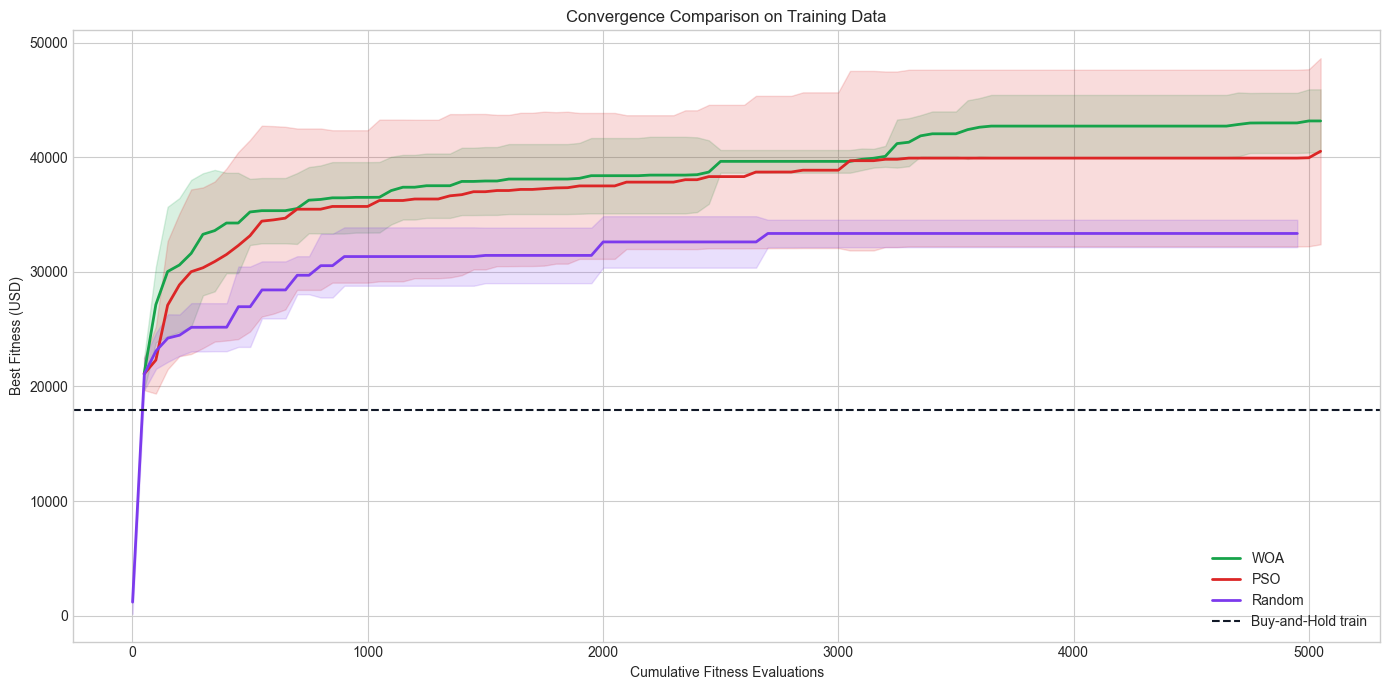

In [37]:
fig, ax = plt.subplots(figsize=(14, 7))
for algorithm in ["WOA", "PSO", "Random"]:
    eval_axis, mean_history, std_history = stacked_histories(complex_results[algorithm])
    if algorithm == "Random":
        step = 50
        eval_plot = eval_axis[::step]
        mean_plot = mean_history[::step]
        std_plot = std_history[::step]
    else:
        eval_plot = eval_axis
        mean_plot = mean_history
        std_plot = std_history
    color = ALGORITHM_COLORS[algorithm]
    ax.plot(eval_plot, mean_plot, label=algorithm, color=color, linewidth=2)
    ax.fill_between(eval_plot, mean_plot - std_plot, mean_plot + std_plot, color=color, alpha=0.16)

ax.axhline(buy_hold_train, color="#111827", linestyle="--", linewidth=1.5, label="Buy-and-Hold train")
ax.set_title("Convergence Comparison on Training Data")
ax.set_xlabel("Cumulative Fitness Evaluations")
ax.set_ylabel("Best Fitness (USD)")
ax.legend(loc="lower right")
fig.tight_layout()
save_figure(fig, "convergence_comparison.png")
plt.show()

The convergence curves show the best-so-far training fitness of WOA, PSO, and Random Search. The shaded regions show variation across seeds, making it easier to compare search speed and stability.

### 9.2 Fitness Summary Table

This table summarises the mean, standard deviation, and best values of train/test fitness.

In [38]:
display_columns = [
    "Algorithm", "Bot Type", "Train Mean", "Train Std", "Test Mean", "Test Std", "Best Train", "Best Test", "Mean Time (s)"
]
formatted_summary = experiment_summary[display_columns].copy()
for column in ["Train Mean", "Train Std", "Test Mean", "Test Std", "Best Train", "Best Test"]:
    formatted_summary[column] = formatted_summary[column].map(lambda value: f"${value:,.2f}")
formatted_summary["Mean Time (s)"] = formatted_summary["Mean Time (s)"].map(lambda value: f"{value:.1f}")
formatted_summary

,Algorithm,Bot Type,Train Mean,Train Std,Test Mean,Test Std,Best Train,Best Test,Mean Time (s)
0,WOA,Complex 14D,"$43,158.94","$2,756.82","$4,237.88",$942.76,"$46,659.45","$5,862.44",1.1
1,PSO,Complex 14D,"$40,516.05","$8,117.21","$3,796.67",$306.14,"$48,682.82","$4,099.03",1.2
2,Random,Complex 14D,"$33,344.62","$1,194.62","$5,358.84","$2,194.48","$34,675.83","$7,604.03",1.4
3,WOA,Simple 2D,"$40,753.05",$192.88,$592.93,$54.44,"$40,839.31",$617.28,0.6
4,PSO,Simple 2D,"$40,137.37","$1,569.59",$694.89,$173.55,"$40,839.31","$1,005.34",0.6
5,PSO pop 20,Sensitivity 14D,"$48,183.06","$5,134.77","$3,214.63",$615.55,"$56,514.80","$4,313.97",1.2
6,PSO pop 50,Sensitivity 14D,"$40,516.05","$8,117.21","$3,796.67",$306.14,"$48,682.82","$4,099.03",1.2
7,PSO pop 100,Sensitivity 14D,"$46,206.21","$5,590.83","$3,703.54",$297.13,"$55,907.55","$3,928.40",1.3
8,Buy-and-Hold,Baseline,"$17,924.71",$0.00,"$5,660.26",$0.00,"$17,924.71","$5,660.26",0.0


### 9.3 Fitness Distributions

The boxplots show the train/test fitness distributions across five independent runs, which helps examine algorithm stability and generalisation gaps.

Saved figure: ./outputs/figures/fitness_boxplots.png


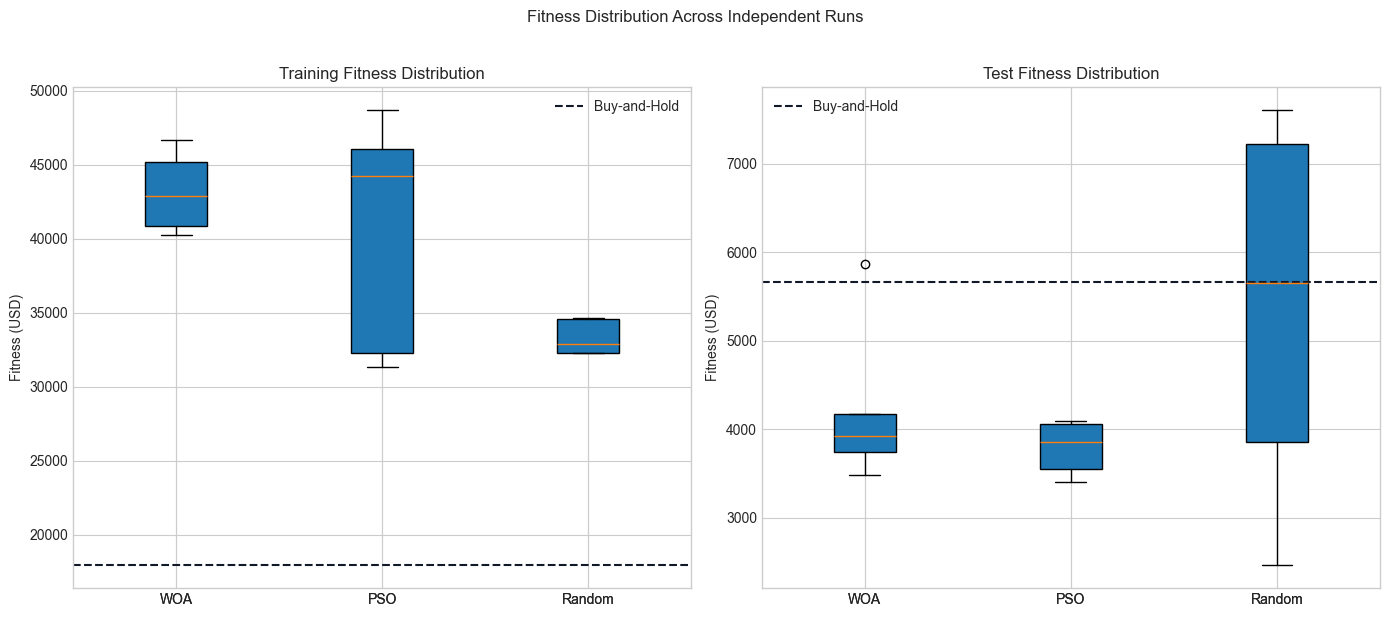

In [39]:
complex_algorithms = ["WOA", "PSO", "Random"]
train_box_values = [complex_results[algorithm]["train_fitness"] for algorithm in complex_algorithms]
test_box_values = [complex_results[algorithm]["test_fitness"] for algorithm in complex_algorithms]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
axes[0].boxplot(train_box_values, tick_labels=complex_algorithms, patch_artist=True)
axes[0].axhline(buy_hold_train, color="#111827", linestyle="--", linewidth=1.5, label="Buy-and-Hold")
axes[0].set_title("Training Fitness Distribution")
axes[0].set_ylabel("Fitness (USD)")
axes[0].legend(loc="best")

axes[1].boxplot(test_box_values, tick_labels=complex_algorithms, patch_artist=True)
axes[1].axhline(buy_hold_test, color="#111827", linestyle="--", linewidth=1.5, label="Buy-and-Hold")
axes[1].set_title("Test Fitness Distribution")
axes[1].set_ylabel("Fitness (USD)")
axes[1].legend(loc="best")

fig.suptitle("Fitness Distribution Across Independent Runs", y=1.02)
fig.tight_layout()
save_figure(fig, "fitness_boxplots.png")
plt.show()

### 9.4 Best Bot Trading Visualisation

First, the run with the best test fitness is selected for each 14-dimensional method, and the test-set price with the actual buy/sell points is plotted. Then, the globally best test Bot is visualised in more detail with HIGH/LOW signals and its equity curve.

In [40]:
best_complex_runs = {}
for algorithm in complex_algorithms:
    idx, solution, train_fit, test_fit = best_run_by_test(complex_results[algorithm])
    best_complex_runs[algorithm] = {
        "run_index": idx,
        "solution": solution,
        "train_fitness": train_fit,
        "test_fitness": test_fit,
    }

best_run_table = pd.DataFrame([
    {
        "Algorithm": algorithm,
        "Run Index": info["run_index"],
        "Train Fitness": info["train_fitness"],
        "Test Fitness": info["test_fitness"],
    }
    for algorithm, info in best_complex_runs.items()
]).sort_values("Test Fitness", ascending=False)

best_overall_algorithm = best_run_table.iloc[0]["Algorithm"]
best_overall_solution = best_complex_runs[best_overall_algorithm]["solution"]
best_overall_test = best_complex_runs[best_overall_algorithm]["test_fitness"]

print(f"Best overall test bot: {best_overall_algorithm}, test fitness ${best_overall_test:.2f}")
best_run_table

Best overall test bot: Random, test fitness $7604.03


,Algorithm,Run Index,Train Fitness,Test Fitness
2,Random,4,32300.703625,7604.033605
0,WOA,3,46659.447797,5862.437999
1,PSO,0,31306.113507,4099.028450


This cell identifies the best test-set run for each 14-dimensional method. These best test solutions, rather than the training-set optima, are used for the later trading-point plots.

Saved figure: ./outputs/figures/best_trading_points_by_algorithm.png


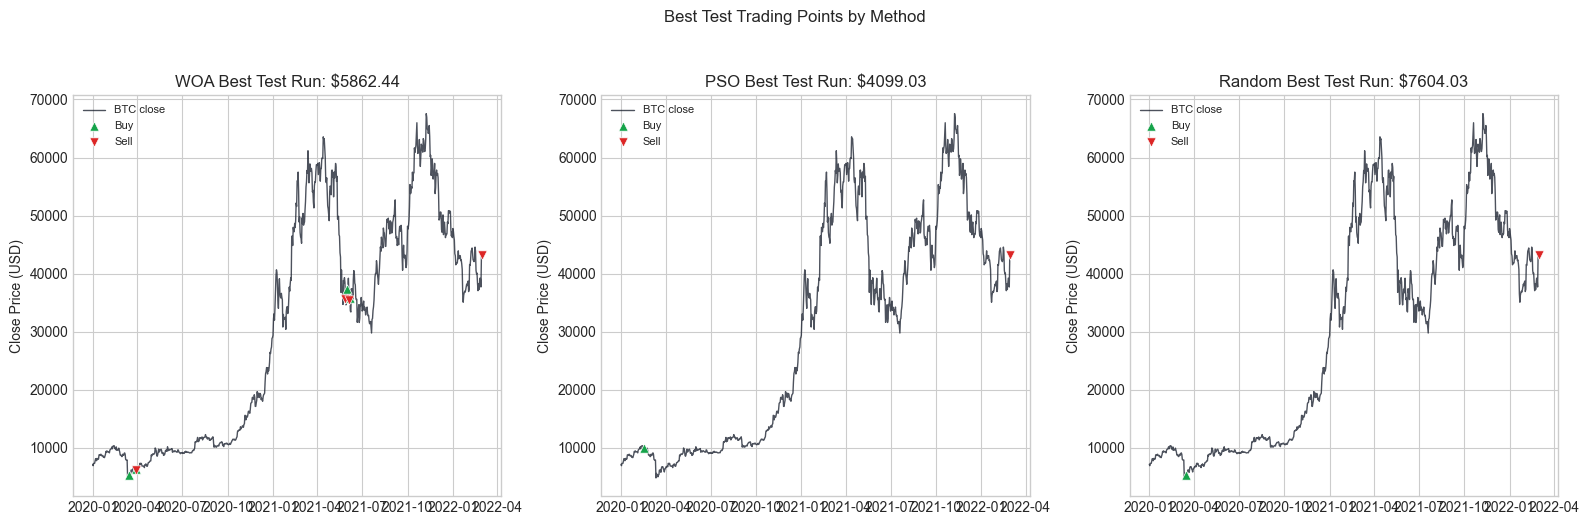

In [41]:
fig, axes = plt.subplots(1, len(complex_algorithms), figsize=(16, 5), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, algorithm in zip(axes, complex_algorithms):
    info = best_complex_runs[algorithm]
    equity, trades, high_signal, low_signal = equity_curve_from_solution(test_data, info["solution"], bot_type="complex")
    buy_indices = [trade["index"] for trade in trades if trade["action"] == "buy"]
    sell_indices = [trade["index"] for trade in trades if trade["action"] in ["sell", "final_sell"]]

    ax.plot(test_prices.index, test_data, color="#111827", linewidth=1.0, alpha=0.75, label="BTC close")
    if buy_indices:
        ax.scatter(test_prices.index[buy_indices], test_data[buy_indices], marker="^", s=45,
                   color="#16a34a", edgecolor="white", linewidth=0.5, label="Buy", zorder=5)
    if sell_indices:
        ax.scatter(test_prices.index[sell_indices], test_data[sell_indices], marker="v", s=45,
                   color="#dc2626", edgecolor="white", linewidth=0.5, label="Sell", zorder=5)
    ax.set_title(f"{algorithm} Best Test Run: ${info['test_fitness']:.2f}")
    ax.set_ylabel("Close Price (USD)")
    ax.legend(loc="upper left", fontsize=8)

fig.suptitle("Best Test Trading Points by Method", y=1.04)
fig.tight_layout()
save_figure(fig, "best_trading_points_by_algorithm.png")
plt.show()

This set of figures compares the best test strategies found by WOA, PSO, and Random Search over the same test period. The trading rhythms differ across methods: some are more conservative, while others depend more heavily on specific entry points.

Saved figure: ./outputs/figures/best_overall_trading_detail.png


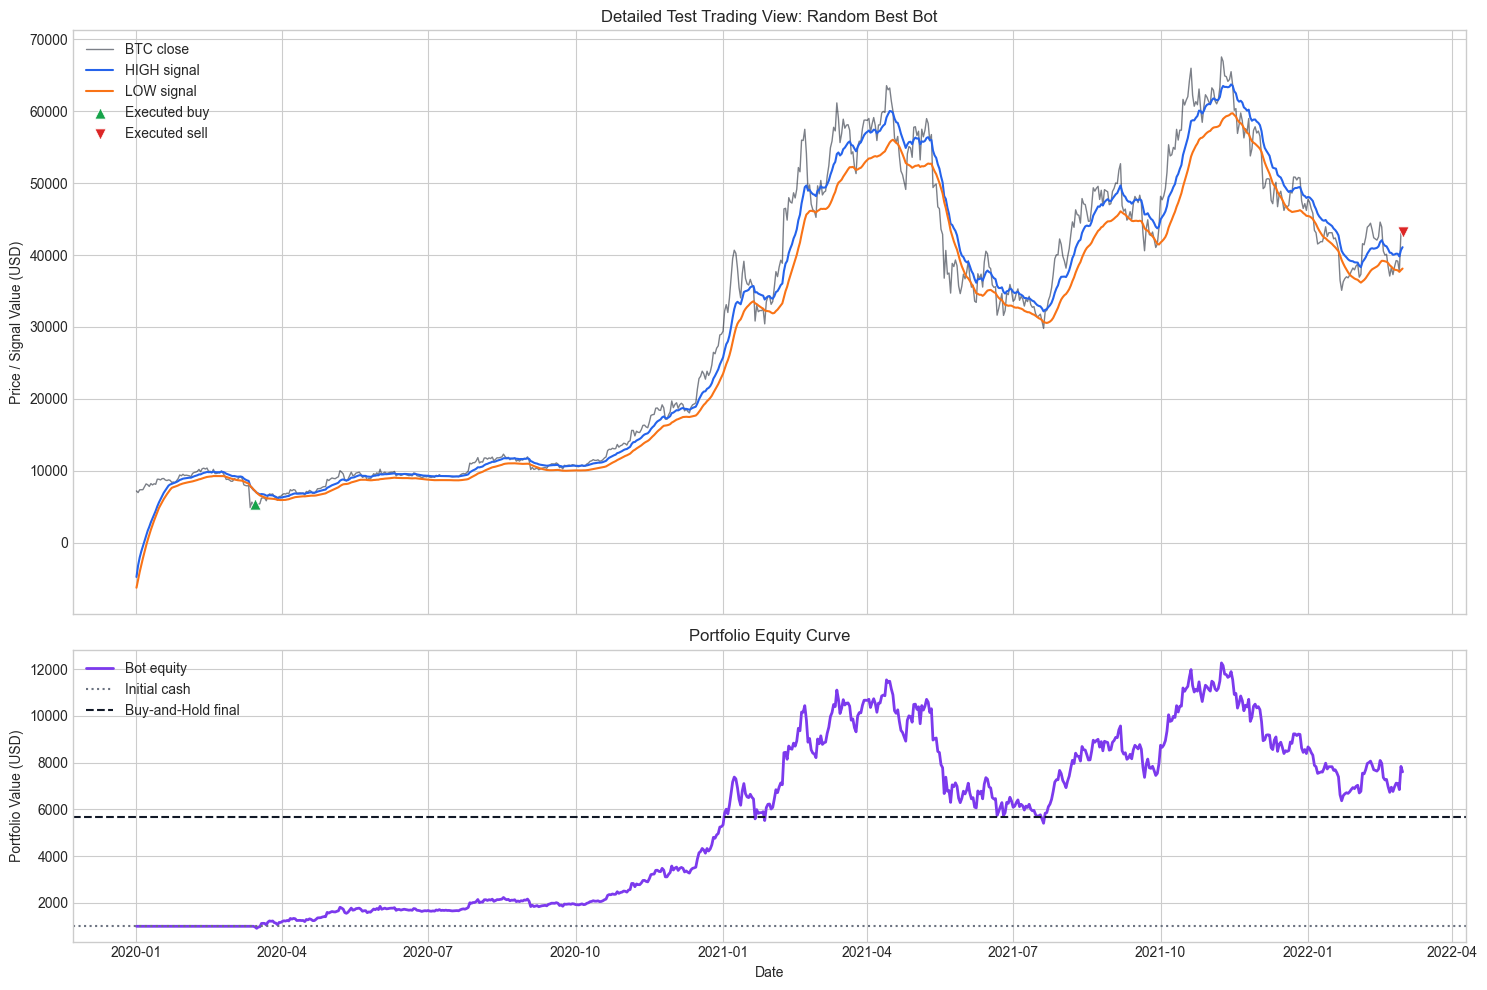

Best bot executed trades on test data: 2


In [42]:
best_equity, best_trades, best_high, best_low = equity_curve_from_solution(
    test_data, best_overall_solution, bot_type="complex"
)
best_buy_indices = [trade["index"] for trade in best_trades if trade["action"] == "buy"]
best_sell_indices = [trade["index"] for trade in best_trades if trade["action"] in ["sell", "final_sell"]]

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(test_prices.index, test_data, color="#111827", linewidth=1.0, alpha=0.55, label="BTC close")
axes[0].plot(test_prices.index, best_high, color="#2563eb", linewidth=1.5, label="HIGH signal")
axes[0].plot(test_prices.index, best_low, color="#f97316", linewidth=1.5, label="LOW signal")
if best_buy_indices:
    axes[0].scatter(test_prices.index[best_buy_indices], test_data[best_buy_indices], marker="^", s=65,
                    color="#16a34a", edgecolor="white", linewidth=0.6, label="Executed buy", zorder=5)
if best_sell_indices:
    axes[0].scatter(test_prices.index[best_sell_indices], test_data[best_sell_indices], marker="v", s=65,
                    color="#dc2626", edgecolor="white", linewidth=0.6, label="Executed sell", zorder=5)
axes[0].set_title(f"Detailed Test Trading View: {best_overall_algorithm} Best Bot")
axes[0].set_ylabel("Price / Signal Value (USD)")
axes[0].legend(loc="upper left")

axes[1].plot(test_prices.index, best_equity, color="#7c3aed", linewidth=2, label="Bot equity")
axes[1].axhline(INITIAL_CASH, color="#6b7280", linestyle=":", linewidth=1.5, label="Initial cash")
axes[1].axhline(buy_hold_test, color="#111827", linestyle="--", linewidth=1.5, label="Buy-and-Hold final")
axes[1].set_title("Portfolio Equity Curve")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Portfolio Value (USD)")
axes[1].legend(loc="upper left")

fig.tight_layout()
save_figure(fig, "best_overall_trading_detail.png")
plt.show()

print(f"Best bot executed trades on test data: {len(best_trades)}")

The global best test Bot is expanded here into HIGH/LOW signals, trading points, and an equity curve.

### 9.5 2D vs 14D Bot Comparison

This figure compares the average train/test fitness of WOA and PSO on the 14-dimensional compound Bot and the 2-dimensional Simple Bot. It is used to discuss hypothesis-space complexity and generalisation performance.

Saved figure: ./outputs/figures/dimension_comparison.png


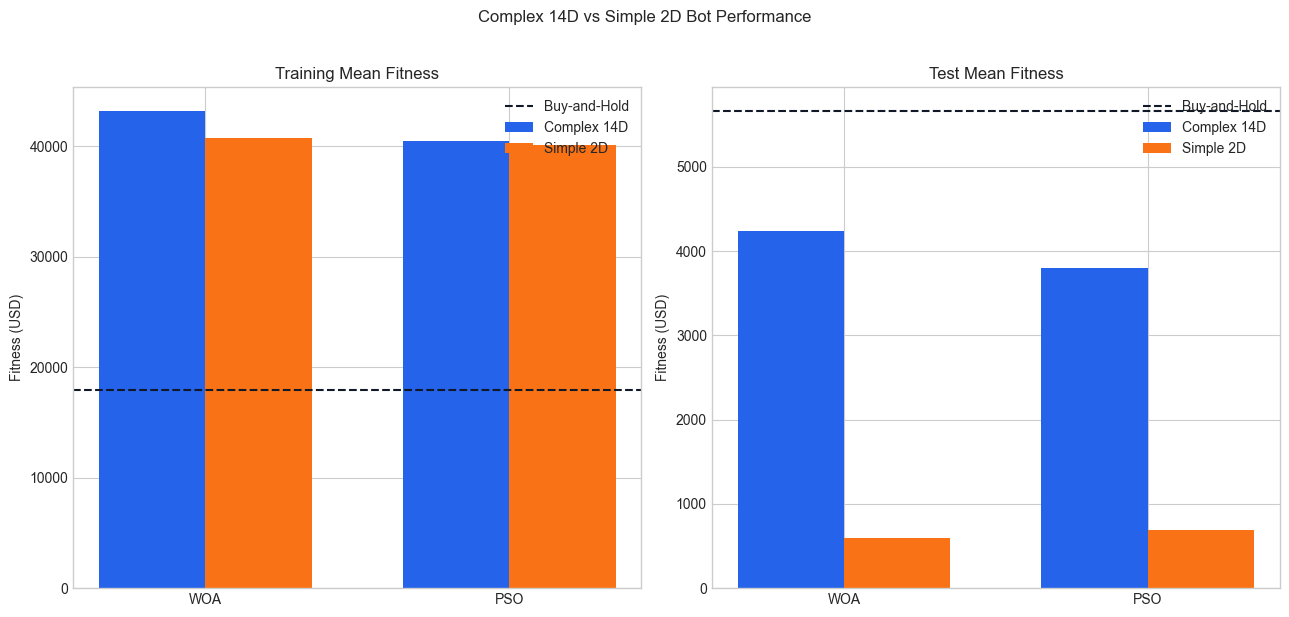

,Algorithm,Bot Type,Train Mean,Test Mean
0,WOA,Complex 14D,43158.935009,4237.882744
1,WOA,Simple 2D,40753.052030,592.930033
2,PSO,Complex 14D,40516.046953,3796.665031
3,PSO,Simple 2D,40137.366742,694.889491


In [43]:
dimension_rows = []
for algorithm in ["WOA", "PSO"]:
    dimension_rows.append({
        "Algorithm": algorithm,
        "Bot Type": "Complex 14D",
        "Train Mean": np.mean(complex_results[algorithm]["train_fitness"]),
        "Test Mean": np.mean(complex_results[algorithm]["test_fitness"]),
    })
    dimension_rows.append({
        "Algorithm": algorithm,
        "Bot Type": "Simple 2D",
        "Train Mean": np.mean(simple_results[algorithm]["train_fitness"]),
        "Test Mean": np.mean(simple_results[algorithm]["test_fitness"]),
    })

dimension_df = pd.DataFrame(dimension_rows)
comparison_algorithms = ["WOA", "PSO"]

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=False)
bar_width = 0.35
x = np.arange(len(comparison_algorithms))
for ax, metric, title in zip(axes, ["Train Mean", "Test Mean"], ["Training Mean Fitness", "Test Mean Fitness"]):
    complex_values = [dimension_df[(dimension_df["Algorithm"] == alg) & (dimension_df["Bot Type"] == "Complex 14D")][metric].iloc[0] for alg in comparison_algorithms]
    simple_values = [dimension_df[(dimension_df["Algorithm"] == alg) & (dimension_df["Bot Type"] == "Simple 2D")][metric].iloc[0] for alg in comparison_algorithms]
    ax.bar(x - bar_width / 2, complex_values, width=bar_width, label="Complex 14D", color="#2563eb")
    ax.bar(x + bar_width / 2, simple_values, width=bar_width, label="Simple 2D", color="#f97316")
    baseline = buy_hold_train if metric == "Train Mean" else buy_hold_test
    ax.axhline(baseline, color="#111827", linestyle="--", linewidth=1.5, label="Buy-and-Hold")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(comparison_algorithms)
    ax.set_ylabel("Fitness (USD)")
    ax.legend(loc="best")

fig.suptitle("Complex 14D vs Simple 2D Bot Performance", y=1.02)
fig.tight_layout()
save_figure(fig, "dimension_comparison.png")
plt.show()
dimension_df

This figure compares the performance of the 14-dimensional compound Bot and the 2-dimensional Simple Bot under WOA and PSO. The result shows that the larger parameter space improves expressiveness, but does not automatically solve the generalisation problem.

### 9.6 PSO Population Size Sensitivity

This figure compares PSO convergence behaviour under different population sizes while keeping the total evaluation budget fixed.

Saved figure: ./outputs/figures/pso_population_sensitivity.png


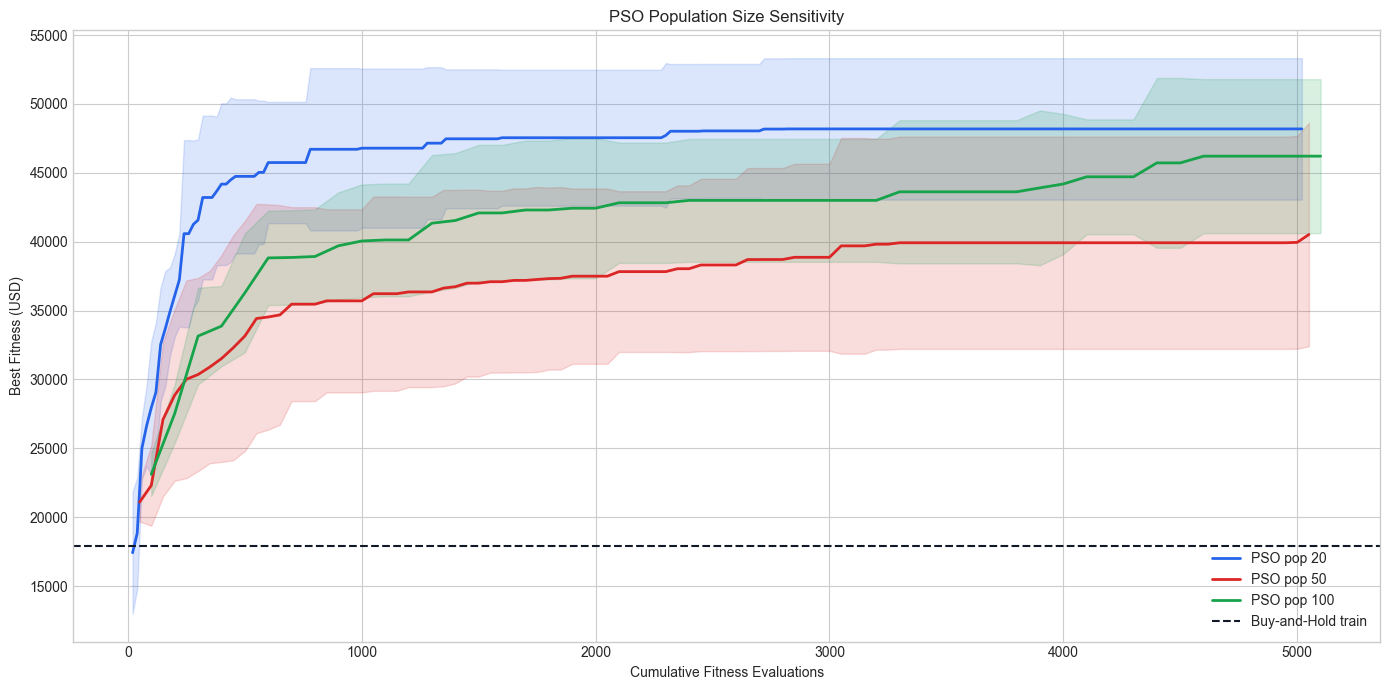

In [44]:
fig, ax = plt.subplots(figsize=(14, 7))
sensitivity_colors = {20: "#2563eb", 50: "#dc2626", 100: "#16a34a"}
for pop_size in POP_SIZES_TO_TEST:
    eval_axis, mean_history, std_history = stacked_histories(sensitivity_results[pop_size])
    color = sensitivity_colors[pop_size]
    ax.plot(eval_axis, mean_history, color=color, linewidth=2, label=f"PSO pop {pop_size}")
    ax.fill_between(eval_axis, mean_history - std_history, mean_history + std_history, color=color, alpha=0.16)

ax.axhline(buy_hold_train, color="#111827", linestyle="--", linewidth=1.5, label="Buy-and-Hold train")
ax.set_title("PSO Population Size Sensitivity")
ax.set_xlabel("Cumulative Fitness Evaluations")
ax.set_ylabel("Best Fitness (USD)")
ax.legend(loc="lower right")
fig.tight_layout()
save_figure(fig, "pso_population_sensitivity.png")
plt.show()

Saved figure: outputs/figures/pso_population_test_performance.png


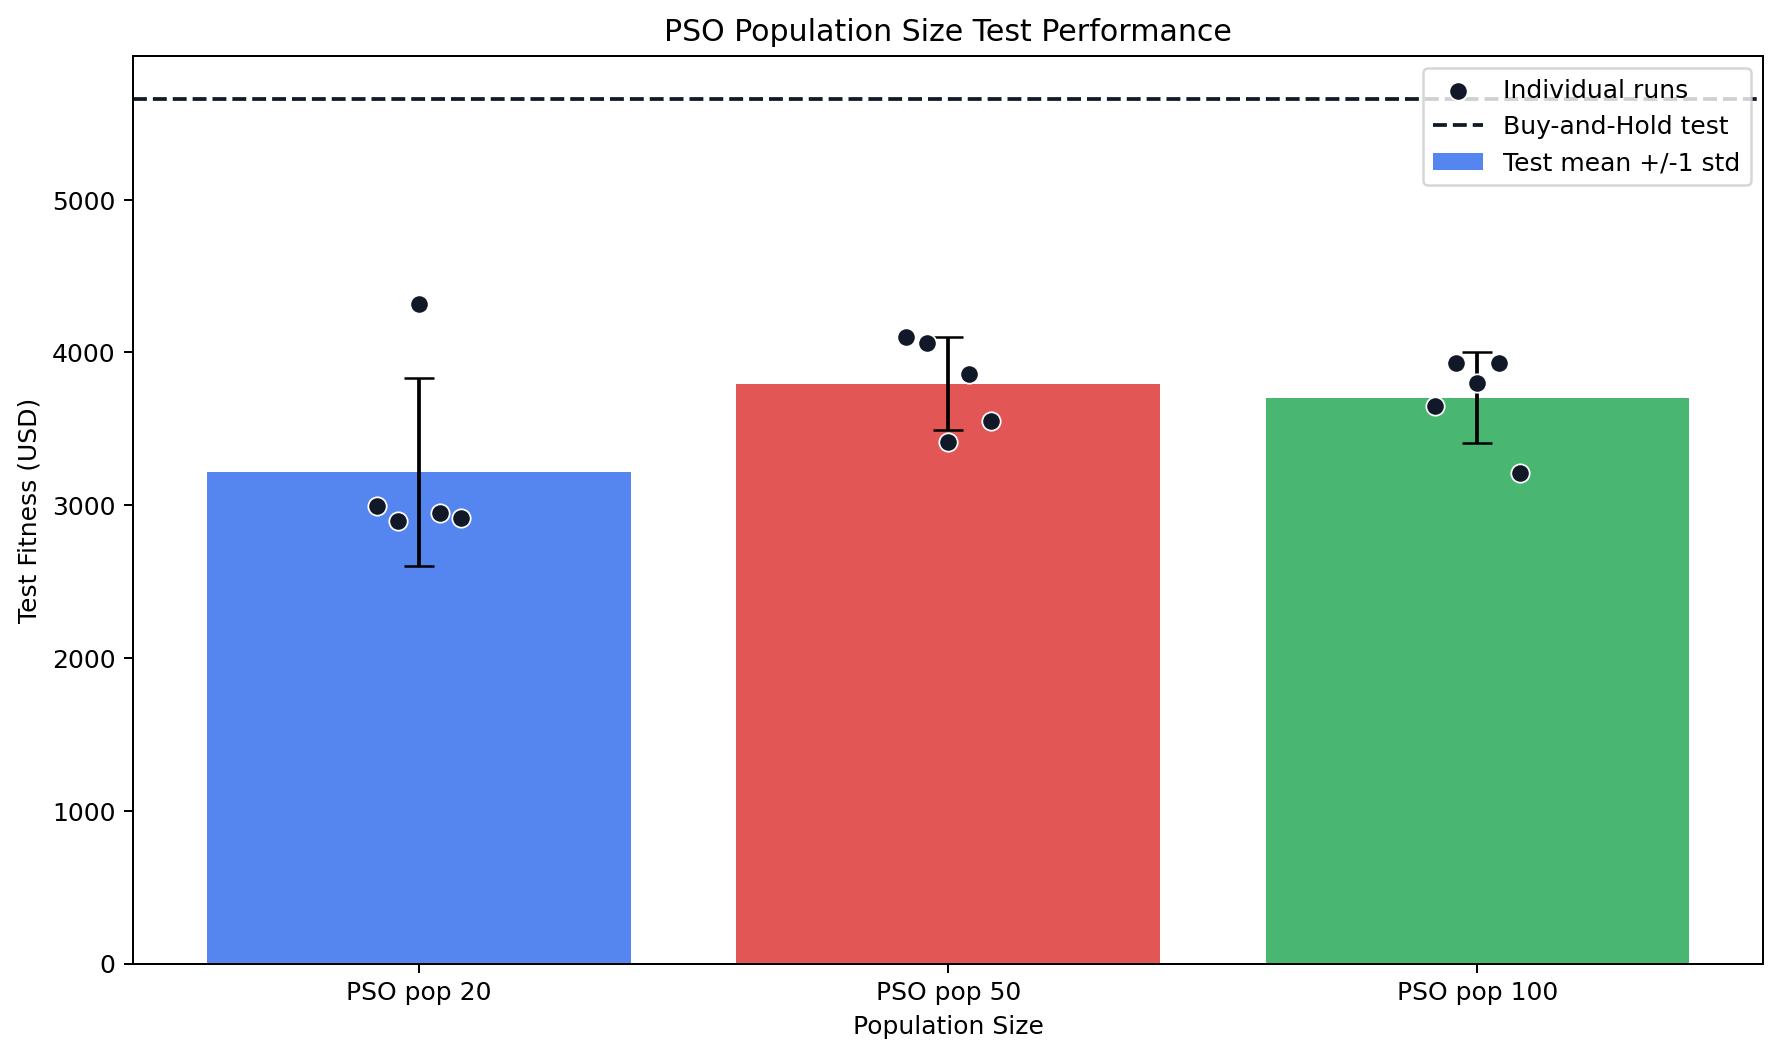

In [45]:
sensitivity_test_means = []
sensitivity_test_stds = []
sensitivity_test_values = []
for pop_size in POP_SIZES_TO_TEST:
    values = np.array(sensitivity_results[pop_size]["test_fitness"], dtype=float)
    sensitivity_test_values.append(values)
    sensitivity_test_means.append(values.mean())
    sensitivity_test_stds.append(values.std(ddof=1) if len(values) > 1 else 0.0)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(POP_SIZES_TO_TEST))
bar_colors = [sensitivity_colors[pop_size] for pop_size in POP_SIZES_TO_TEST]
bar_labels = [f"PSO pop {pop_size}" for pop_size in POP_SIZES_TO_TEST]
ax.bar(x, sensitivity_test_means, yerr=sensitivity_test_stds, capsize=6,
       color=bar_colors, alpha=0.78, label="Test mean ±1 std")

for position, values in zip(x, sensitivity_test_values):
    jitter = np.linspace(-0.08, 0.08, len(values)) if len(values) > 1 else np.array([0.0])
    ax.scatter(
        np.full(len(values), position) + jitter,
        values,
        color="#111827",
        edgecolor="white",
        linewidth=0.7,
        s=54,
        zorder=3,
        label="Individual runs" if position == 0 else None,
    )

ax.axhline(buy_hold_test, color="#111827", linestyle="--", linewidth=1.5, label="Buy-and-Hold test")
ax.set_title("PSO Population Size Test Performance")
ax.set_xlabel("Population Size")
ax.set_ylabel("Test Fitness (USD)")
ax.set_xticks(x)
ax.set_xticklabels(bar_labels)
ax.legend(loc="best")
fig.tight_layout()
save_figure(fig, "pso_population_test_performance.png")
plt.show()


This figure complements the previous PSO training convergence curve by comparing the final generalisation performance of population sizes 20, 50, and 100 on the unseen test set. It shows the test fitness of each seed's final best training solution, not test convergence across iterations.

PSO population size sensitivity shows how different population sizes converge under the same evaluation budget. The main focus here is the trade-off between exploration breadth and the number of available iterations.

### 9.7 Parameter Weight Analysis

This section analyses the parameters from the best test-set run of each 14-dimensional algorithm: the SMA/LMA/EMA weight proportions in HIGH/LOW, and the HIGH/LOW window lengths.

Saved figure: ./outputs/figures/parameter_weight_analysis.png


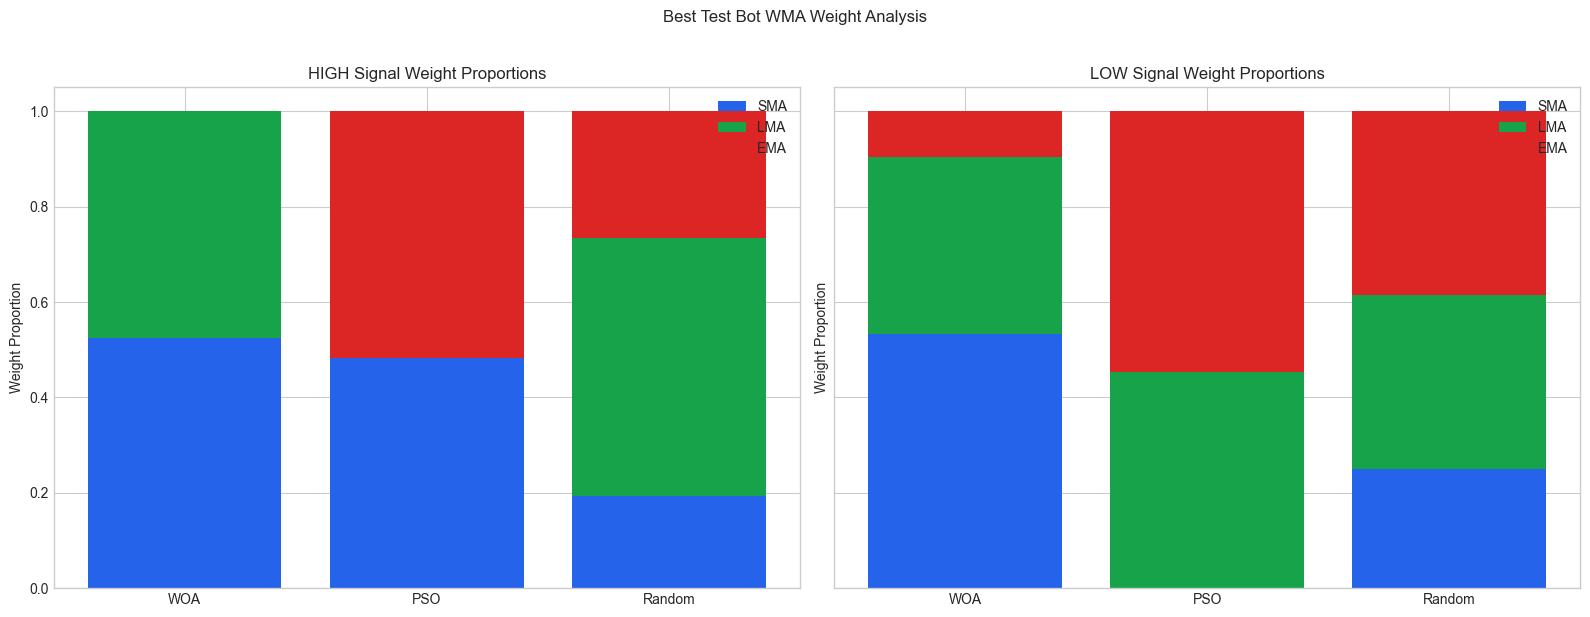

Saved figure: ./outputs/figures/parameter_window_analysis.png


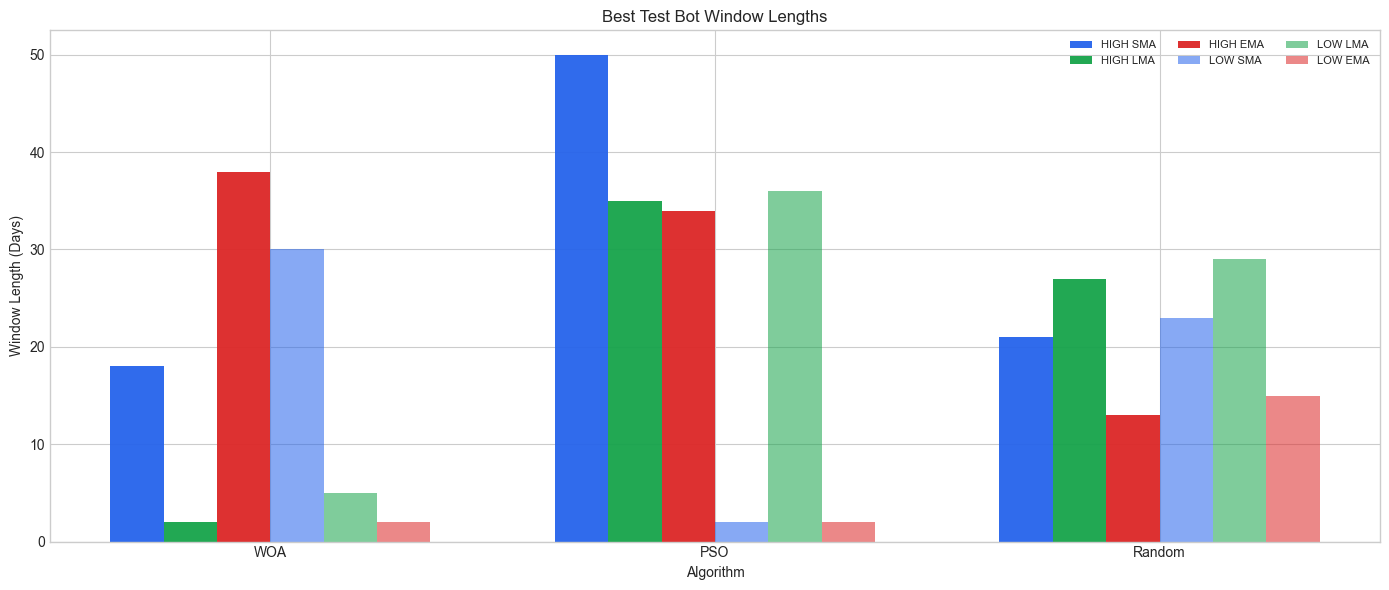

Weight proportions:


,Algorithm,Signal,Component,Weight
0,WOA,HIGH,SMA,0.524961
1,WOA,HIGH,LMA,0.475039
2,WOA,HIGH,EMA,0.000000
3,WOA,LOW,SMA,0.533917
4,WOA,LOW,LMA,0.369753
5,WOA,LOW,EMA,0.096330
6,PSO,HIGH,SMA,0.481819
7,PSO,HIGH,LMA,0.000000
8,PSO,HIGH,EMA,0.518181
9,PSO,LOW,SMA,0.000000


Window lengths:


,Algorithm,Signal,Component,Window
0,WOA,HIGH,SMA,18.0
1,WOA,HIGH,LMA,2.0
2,WOA,HIGH,EMA,38.0
3,WOA,LOW,SMA,30.0
4,WOA,LOW,LMA,5.0
5,WOA,LOW,EMA,2.0
6,PSO,HIGH,SMA,50.0
7,PSO,HIGH,LMA,35.0
8,PSO,HIGH,EMA,34.0
9,PSO,LOW,SMA,2.0


In [46]:
def normalised_weights(values):
    """Convert raw component weights into proportions."""
    values = np.asarray(values, dtype=float)
    total = values.sum()
    if total < 1e-10:
        return np.zeros_like(values)
    return values / total

weight_rows = []
duration_rows = []
for algorithm, info in best_complex_runs.items():
    solution = clip_solution(info["solution"])
    high_weights = normalised_weights(solution[[0, 1, 2]])
    low_weights = normalised_weights(solution[[7, 8, 9]])
    for component, value in zip(["SMA", "LMA", "EMA"], high_weights):
        weight_rows.append({"Algorithm": algorithm, "Signal": "HIGH", "Component": component, "Weight": value})
    for component, value in zip(["SMA", "LMA", "EMA"], low_weights):
        weight_rows.append({"Algorithm": algorithm, "Signal": "LOW", "Component": component, "Weight": value})
    for signal, indices in [("HIGH", [3, 4, 5]), ("LOW", [10, 11, 12])]:
        for component, idx in zip(["SMA", "LMA", "EMA"], indices):
            duration_rows.append({"Algorithm": algorithm, "Signal": signal, "Component": component, "Window": solution[idx]})

weight_df = pd.DataFrame(weight_rows)
duration_df = pd.DataFrame(duration_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
component_colors = {"SMA": "#2563eb", "LMA": "#16a34a", "EMA": "#dc2626"}
for ax, signal in zip(axes, ["HIGH", "LOW"]):
    bottom = np.zeros(len(complex_algorithms))
    for component in ["SMA", "LMA", "EMA"]:
        values = [
            weight_df[(weight_df["Algorithm"] == alg) & (weight_df["Signal"] == signal) & (weight_df["Component"] == component)]["Weight"].iloc[0]
            for alg in complex_algorithms
        ]
        ax.bar(complex_algorithms, values, bottom=bottom, label=component, color=component_colors[component])
        bottom += np.array(values)
    ax.set_title(f"{signal} Signal Weight Proportions")
    ax.set_ylabel("Weight Proportion")
    ax.set_ylim(0, 1.05)
    ax.legend(loc="upper right")

fig.suptitle("Best Test Bot WMA Weight Analysis", y=1.02)
fig.tight_layout()
save_figure(fig, "parameter_weight_analysis.png")
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
bar_positions = np.arange(len(complex_algorithms))
bar_width = 0.12
offsets = {
    ("HIGH", "SMA"): -2.5,
    ("HIGH", "LMA"): -1.5,
    ("HIGH", "EMA"): -0.5,
    ("LOW", "SMA"): 0.5,
    ("LOW", "LMA"): 1.5,
    ("LOW", "EMA"): 2.5,
}
for (signal, component), offset in offsets.items():
    values = [
        duration_df[(duration_df["Algorithm"] == alg) & (duration_df["Signal"] == signal) & (duration_df["Component"] == component)]["Window"].iloc[0]
        for alg in complex_algorithms
    ]
    color = component_colors[component]
    alpha = 0.95 if signal == "HIGH" else 0.55
    ax.bar(bar_positions + offset * bar_width, values, width=bar_width, color=color, alpha=alpha, label=f"{signal} {component}")

ax.set_title("Best Test Bot Window Lengths")
ax.set_xlabel("Algorithm")
ax.set_ylabel("Window Length (Days)")
ax.set_xticks(bar_positions)
ax.set_xticklabels(complex_algorithms)
ax.legend(ncol=3, fontsize=8)
fig.tight_layout()
save_figure(fig, "parameter_window_analysis.png")
plt.show()

print("Weight proportions:")
display(weight_df)
print("Window lengths:")
display(duration_df)

### 9.8 Key Findings


In [47]:
complex_summary = experiment_summary[experiment_summary["Bot Type"] == "Complex 14D"].copy()
nature_algorithms = ["WOA", "PSO"]
nature_summary = complex_summary[complex_summary["Algorithm"].isin(nature_algorithms)]

best_mean_test_algorithm = complex_summary.loc[complex_summary["Test Mean"].idxmax(), "Algorithm"]
best_nature_mean_test_algorithm = nature_summary.loc[nature_summary["Test Mean"].idxmax(), "Algorithm"]
best_single_test_row = complex_summary.loc[complex_summary["Best Test"].idxmax()]
best_train_algorithm = complex_summary.loc[complex_summary["Train Mean"].idxmax(), "Algorithm"]

simple_test_mean = experiment_summary[experiment_summary["Bot Type"] == "Simple 2D"]["Test Mean"].mean()
complex_nature_test_mean = nature_summary["Test Mean"].mean()

overfit_rows = []
for algorithm in nature_algorithms:
    row = nature_summary[nature_summary["Algorithm"] == algorithm].iloc[0]
    overfit_rows.append({
        "Algorithm": algorithm,
        "Train Mean": row["Train Mean"],
        "Test Mean": row["Test Mean"],
        "Train/Test Ratio": row["Train Mean"] / row["Test Mean"],
    })
overfit_df = pd.DataFrame(overfit_rows)

print(f"Best mean test fitness among all 14D methods: {best_mean_test_algorithm}")
print(f"Best mean test fitness among WOA/PSO: {best_nature_mean_test_algorithm}")
print(f"Best single test run: {best_single_test_row['Algorithm']} (${best_single_test_row['Best Test']:.2f})")
print(f"Best mean training fitness: {best_train_algorithm}")
print(f"Mean test fitness, complex WOA/PSO: ${complex_nature_test_mean:.2f}")
print(f"Mean test fitness, simple WOA/PSO: ${simple_test_mean:.2f}")
print(f"Buy-and-Hold test fitness: ${buy_hold_test:.2f}")
print("Overfitting indicators:")
overfit_df

Best mean test fitness among all 14D methods: Random
Best mean test fitness among WOA/PSO: WOA
Best single test run: Random ($7604.03)
Best mean training fitness: WOA
Mean test fitness, complex WOA/PSO: $4017.27
Mean test fitness, simple WOA/PSO: $643.91
Buy-and-Hold test fitness: $5660.26
Overfitting indicators:


,Algorithm,Train Mean,Test Mean,Train/Test Ratio
0,WOA,43158.935009,4237.882744,10.184080
1,PSO,40516.046953,3796.665031,10.671483
